In [ ]:
!ls -la

total 24
drwxr-xr-x 1 root root 4096 Sep  7 02:53 .
drwxr-xr-x 1 root root 4096 Sep  7 02:43 ..
drwxr-xr-x 4 root root 4096 Aug 24 13:27 .config
-rw-r--r-- 1 root root   69 Sep  7 02:52 kaggle.json
drwxr-xr-x 3 root root 4096 Sep  7 02:53 MammoGraph
drwxr-xr-x 1 root root 4096 Aug 24 13:28 sample_data


In [ ]:
!pip -q install kaggle

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s vindr-mammogram

ref                                                 title                                       size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------  ------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shantanughosh/vindr-mammogram-dataset-dicom-to-png  VinDr Mammogram dataset Dicom to png  8251039114  2024-06-23 03:20:32.003000           3305         22  0.625            
vbookshelf/mammogram-mass-analyzer-v00              Mammogram Mass Analyzer Desktop App    207834390  2022-12-29 03:00:59.813000            378         14  0.625            


In [ ]:
!mkdir -p /content/MammoGraph/dataset

In [ ]:
!kaggle datasets download \
    -d shantanughosh/vindr-mammogram-dataset-dicom-to-png \
    -p /content/MammoGraph/dataset

Dataset URL: https://www.kaggle.com/datasets/shantanughosh/vindr-mammogram-dataset-dicom-to-png
License(s): CC-BY-NC-SA-4.0
100% 7.68G/7.68G [01:28<00:00, 93.4MB/s]



In [ ]:
!unzip -l /content/MammoGraph/dataset/vindr-mammogram-dataset-dicom-to-png.zip | head -30

Archive:  /content/MammoGraph/dataset/vindr-mammogram-dataset-dicom-to-png.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
   442407  2024-06-23 03:23   images_png/0025a5dc99fd5c742026f0b2b030d3e9/2ddfad7286c2b016931ceccd1e2c7bbc.png
   366322  2024-06-23 03:23   images_png/0025a5dc99fd5c742026f0b2b030d3e9/451562831387e2822923204cf8f0873e.png
   444199  2024-06-23 03:23   images_png/0025a5dc99fd5c742026f0b2b030d3e9/47c8858666bcce92bcbd57974b5ce522.png
   367476  2024-06-23 03:23   images_png/0025a5dc99fd5c742026f0b2b030d3e9/fcf12c2803ba8dc564bf1287c0c97d9a.png
   449664  2024-06-23 03:23   images_png/0028fb2c7f0b3a5cb9a80cb0e1cdbb91/16e58fc1d65fa7587247e6224ee96527.png
   392151  2024-06-23 03:23   images_png/0028fb2c7f0b3a5cb9a80cb0e1cdbb91/3704f91985dcbc69f6ac2803523d1ecb.png
   485113  2024-06-23 03:23   images_png/0028fb2c7f0b3a5cb9a80cb0e1cdbb91/7fc1f1bb8bb1a7efaf7104e49c4d8b86.png
   383386  2024-06-23 03:23   images_png/0028fb2c7f0b3a5cb9a80cb0e1cdbb91/

In [ ]:
!unzip -q /content/MammoGraph/dataset/vindr-mammogram-dataset-dicom-to-png.zip \
    -d /content/MammoGraph/dataset/

In [ ]:
from pathlib import Path

dataset_dir = Path("/content/MammoGraph/dataset")
image_dir = dataset_dir / "images_png"

study_dirs = [p for p in image_dir.iterdir() if p.is_dir()]

print("Study folders:", len(study_dirs))

if study_dirs:
    first_study = study_dirs[0]
    images = list(first_study.glob("*.png"))
    print("Example study:", first_study.name)
    print("Images in example study:", len(images))
    print("Example images:")
    for img in images:
        print(" ", img.name)

Study folders: 5000
Example study: a4d42bf9c1134be1dc77999efe553c97
Images in example study: 4
Example images:
  fb04090d40d2949cff34cd0e1726a3df.png
  3cdef45e87af9ce95fed666fa8386c18.png
  97bc5e0910de874eec16300587775067.png
  2c1a6a97af8a309d61a5ec562afa3393.png


In [ ]:
!rm /content/MammoGraph/dataset/vindr-mammogram-dataset-dicom-to-png.zip

In [ ]:
!du -sh /content/MammoGraph/dataset

7.8G	/content/MammoGraph/dataset


In [ ]:
!git clone -q https://github.com/batmanlab/Mammo-CLIP.git /content/Mammo-CLIP

In [ ]:
!find /content/Mammo-CLIP -name "vindr_detection_v1_folds.csv"

/content/Mammo-CLIP/src/codebase/data_csv/vindr_detection_v1_folds.csv


In [ ]:
!cp /content/Mammo-CLIP/src/codebase/data_csv/vindr_detection_v1_folds.csv \
    /content/MammoGraph/dataset/

In [ ]:
from pathlib import Path

csv_path = Path("/content/MammoGraph/dataset/vindr_detection_v1_folds.csv")

print("Exists:", csv_path.exists())
print("Size:", round(csv_path.stat().st_size / 1024 / 1024, 2), "MB")

Exists: True
Size: 4.07 MB


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/MammoGraph/dataset/vindr_detection_v1_folds.csv",
    low_memory=False
)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (20486, 33)

Columns:
['patient_id', 'series_id', 'image_id', 'laterality', 'view', 'height', 'width', 'breast_birads', 'breast_density', 'finding_categories', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax', 'split', 'resized_xmin', 'resized_ymin', 'resized_xmax', 'resized_ymax', 'fold', 'Architectural_Distortion', 'Asymmetry', 'Focal_Asymmetry', 'Global_Asymmetry', 'Mass', 'Nipple_Retraction', 'No_Finding', 'Skin_Retraction', 'Skin_Thickening', 'Suspicious_Calcification', 'Suspicious_Lymph_Node', 'density']

First 5 rows:


,patient_id,series_id,image_id,laterality,view,height,width,breast_birads,breast_density,finding_categories,...,Focal_Asymmetry,Global_Asymmetry,Mass,Nipple_Retraction,No_Finding,Skin_Retraction,Skin_Thickening,Suspicious_Calcification,Suspicious_Lymph_Node,density
0,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,4e3a578fe535ea4f5258d3f7f4419db8.png,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Mass'],...,0,0,1,0,0,0,0,0,0,2
1,48575a27b7c992427041a82fa750d3fa,26de4993fa6b8ae50a91c8baf49b92b0,dac39351b0f3a8c670b7f8dc88029364.png,R,MLO,3518,2800,BI-RADS 4,DENSITY C,['Mass'],...,0,0,1,0,0,0,0,0,0,2
2,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,c83f780904f25eacb44e9030f32c66e1.png,R,CC,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],...,0,1,0,0,0,0,0,0,0,2
3,75e8e48933289d70b407379a564f8594,853b70e7e6f39133497909d9ca4c756d,893528bc38a0362928a89364f1b692fd.png,R,MLO,3518,2800,BI-RADS 3,DENSITY C,['Global Asymmetry'],...,0,1,0,0,0,0,0,0,0,2
4,c3487424fee1bdd4515b72dc3fd69813,77619c914263eae44e9099f1ce07192c,318264c881bf12f2c1efe5f93920cc37.png,R,CC,3518,2800,BI-RADS 4,DENSITY C,['Architectural Distortion'],...,0,0,0,0,0,0,0,0,0,2


In [ ]:
from pathlib import Path
import pandas as pd

DATASET_DIR = Path("/content/MammoGraph/dataset")
IMAGE_DIR = DATASET_DIR / "images_png"

df = pd.read_csv(
    DATASET_DIR / "vindr_detection_v1_folds.csv",
    low_memory=False
)

# --------------------------------------------------
# CSV image IDs
# --------------------------------------------------

csv_images = set(df["image_id"].astype(str))

# --------------------------------------------------
# Actual PNG files
# --------------------------------------------------

png_files = list(IMAGE_DIR.glob("*/*.png"))

actual_images = set(
    image.name for image in png_files
)

# --------------------------------------------------
# Compare
# --------------------------------------------------

missing_pngs = csv_images - actual_images
extra_pngs = actual_images - csv_images

print("=" * 60)
print("CSV ↔ PNG INTEGRITY CHECK")
print("=" * 60)

print(f"CSV annotation rows : {len(df):,}")
print(f"Unique CSV images   : {len(csv_images):,}")
print(f"Actual PNG images   : {len(actual_images):,}")

print()
print(f"Missing PNGs        : {len(missing_pngs):,}")
print(f"Extra PNGs          : {len(extra_pngs):,}")

print()
print("Result:")

if not missing_pngs and not extra_pngs:
    print("✓ PERFECT MATCH")
else:
    print("⚠ MISMATCH DETECTED")

    if missing_pngs:
        print("\nExample missing:")
        print(list(missing_pngs)[:10])

    if extra_pngs:
        print("\nExample extra:")
        print(list(extra_pngs)[:10])

CSV ↔ PNG INTEGRITY CHECK
CSV annotation rows : 20,486
Unique CSV images   : 20,000
Actual PNG images   : 20,000

Missing PNGs        : 0
Extra PNGs          : 0

Result:
✓ PERFECT MATCH


In [ ]:
from collections import Counter
from pathlib import Path

image_dir = Path("/content/MammoGraph/dataset/images_png")

study_counts = {}

for study_dir in image_dir.iterdir():
    if study_dir.is_dir():
        png_count = len(list(study_dir.glob("*.png")))
        study_counts[study_dir.name] = png_count

print("Number of studies:", len(study_counts))

distribution = Counter(study_counts.values())

print("\nImages per study:")
for count, num_studies in sorted(distribution.items()):
    print(f"{count} images : {num_studies} studies")

invalid = [
    study_id
    for study_id, count in study_counts.items()
    if count != 4
]

print("\nStudies with != 4 images:", len(invalid))

if invalid:
    print("Example problematic studies:")
    for study_id in invalid[:10]:
        print(study_id, "→", study_counts[study_id])

Number of studies: 5000

Images per study:
4 images : 5000 studies

Studies with != 4 images: 0


In [ ]:
print("Annotation rows by split:")
print(df["split"].value_counts())

print("\nUnique studies by split:")
print(
    df.groupby("split")["patient_id"]
      .nunique()
)

print("\nUnique images by split:")
print(
    df.groupby("split")["image_id"]
      .nunique()
)

Annotation rows by split:
split
training    16391
test         4095
Name: count, dtype: int64

Unique studies by split:
split
test        1000
training    4000
Name: patient_id, dtype: int64

Unique images by split:
split
test         4000
training    16000
Name: image_id, dtype: int64


In [ ]:
train_studies = set(
    df.loc[df["split"] == "training", "patient_id"]
)

test_studies = set(
    df.loc[df["split"] == "test", "patient_id"]
)

overlap = train_studies & test_studies

print("Training studies:", len(train_studies))
print("Test studies:", len(test_studies))
print("Study overlap:", len(overlap))

if len(overlap) == 0:
    print("✓ NO STUDY LEAKAGE")
else:
    print("⚠ STUDY LEAKAGE DETECTED")

Training studies: 4000
Test studies: 1000
Study overlap: 0
✓ NO STUDY LEAKAGE


In [ ]:
from sklearn.model_selection import train_test_split

# Get unique studies from the official training set
training_studies = (
    df.loc[df["split"] == "training", "patient_id"]
    .drop_duplicates()
    .tolist()
)

# Split at study level
train_studies, val_studies = train_test_split(
    training_studies,
    test_size=0.20,
    random_state=42
)

print("Training studies   :", len(train_studies))
print("Validation studies :", len(val_studies))

# Convert to sets for easy membership checking
train_studies = set(train_studies)
val_studies = set(val_studies)

# Build row-level dataframes
train_df = df[
    (df["split"] == "training") &
    (df["patient_id"].isin(train_studies))
].copy()

val_df = df[
    (df["split"] == "training") &
    (df["patient_id"].isin(val_studies))
].copy()

test_df = df[
    df["split"] == "test"
].copy()

print("\nRows:")
print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

Training studies   : 3200
Validation studies : 800

Rows:
Train: 13101
Val  : 3290
Test : 4095


In [ ]:
train_ids = set(train_df["patient_id"])
val_ids = set(val_df["patient_id"])
test_ids = set(test_df["patient_id"])

print("Train studies:", len(train_ids))
print("Val studies  :", len(val_ids))
print("Test studies :", len(test_ids))

print("\nTrain ∩ Val :", len(train_ids & val_ids))
print("Train ∩ Test:", len(train_ids & test_ids))
print("Val ∩ Test  :", len(val_ids & test_ids))

assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0

print("\n✓ ALL STUDY-LEVEL LEAKAGE CHECKS PASSED")

Train studies: 3200
Val studies  : 800
Test studies : 1000

Train ∩ Val : 0
Train ∩ Test: 0
Val ∩ Test  : 0

✓ ALL STUDY-LEVEL LEAKAGE CHECKS PASSED


In [ ]:
from pathlib import Path

split_dir = Path("/content/MammoGraph/dataset/splits")
split_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(split_dir / "train.csv", index=False)
val_df.to_csv(split_dir / "val.csv", index=False)
test_df.to_csv(split_dir / "test.csv", index=False)

print("Saved:")
print(" ", split_dir / "train.csv")
print(" ", split_dir / "val.csv")
print(" ", split_dir / "test.csv")

Saved:
  /content/MammoGraph/dataset/splits/train.csv
  /content/MammoGraph/dataset/splits/val.csv
  /content/MammoGraph/dataset/splits/test.csv


In [ ]:
for name in ["train.csv", "val.csv", "test.csv"]:
    path = split_dir / name
    check = pd.read_csv(path, low_memory=False)

    print(
        f"{name:10s} | "
        f"rows: {len(check):5,} | "
        f"studies: {check['patient_id'].nunique():,} | "
        f"images: {check['image_id'].nunique():,}"
    )

train.csv  | rows: 13,101 | studies: 3,200 | images: 12,800
val.csv    | rows: 3,290 | studies: 800 | images: 3,200
test.csv   | rows: 4,095 | studies: 1,000 | images: 4,000


In [ ]:
import pandas as pd
from pathlib import Path

split_dir = Path("/content/MammoGraph/dataset/splits")

train_df = pd.read_csv(split_dir / "train.csv", low_memory=False)
val_df = pd.read_csv(split_dir / "val.csv", low_memory=False)
test_df = pd.read_csv(split_dir / "test.csv", low_memory=False)

splits = {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}

for split_name, split_df in splits.items():

    print("=" * 60)
    print(split_name)
    print("=" * 60)

    print("Annotation rows:", len(split_df))
    print("Unique images :", split_df["image_id"].nunique())
    print("Unique studies:", split_df["patient_id"].nunique())

    print("\nFinding categories:")

    # Each row may contain multiple findings.
    findings = (
        split_df["finding_categories"]
        .dropna()
        .astype(str)
        .value_counts()
    )

    print(findings)

    print()

Train
Annotation rows: 13101
Unique images : 12800
Unique studies: 3200

Finding categories:
finding_categories
['No Finding']                                                                                      11689
['Mass']                                                                                              721
['Suspicious Calcification']                                                                          234
['Focal Asymmetry']                                                                                   146
['Asymmetry']                                                                                          56
['Suspicious Calcification', 'Mass']                                                                   54
['Architectural Distortion']                                                                           54
['Suspicious Lymph Node']                                                                              40
['Skin Thickening']                     

In [ ]:
import ast
from collections import Counter

FINDING_CLASSES = [
    "Mass",
    "Suspicious Calcification",
    "Focal Asymmetry",
    "Architectural Distortion",
    "Asymmetry",
    "Suspicious Lymph Node",
    "Skin Thickening",
    "Global Asymmetry",
    "Nipple Retraction",
    "Skin Retraction",
]

def get_image_findings(split_df):

    image_findings = {}

    for _, row in split_df.iterrows():

        image_id = row["image_id"]

        value = row["finding_categories"]

        if pd.isna(value):
            continue

        try:
            findings = ast.literal_eval(str(value))
        except (ValueError, SyntaxError):
            findings = [str(value)]

        if not isinstance(findings, list):
            findings = [findings]

        if image_id not in image_findings:
            image_findings[image_id] = set()

        for finding in findings:
            if finding != "No Finding":
                image_findings[image_id].add(finding)

    return image_findings


for split_name, split_df in splits.items():

    image_findings = get_image_findings(split_df)

    counts = Counter()

    for findings in image_findings.values():
        for finding in findings:
            counts[finding] += 1

    no_finding = sum(
        1 for findings in image_findings.values()
        if len(findings) == 0
    )

    print("=" * 60)
    print(split_name)
    print("=" * 60)

    print(f"No Finding: {no_finding:,}")

    for finding in FINDING_CLASSES:
        print(f"{finding:30s}: {counts[finding]:,}")

Train
No Finding: 11,689
Mass                          : 714
Suspicious Calcification      : 257
Focal Asymmetry               : 168
Architectural Distortion      : 64
Asymmetry                     : 62
Suspicious Lymph Node         : 37
Skin Thickening               : 34
Global Asymmetry              : 16
Nipple Retraction             : 23
Skin Retraction               : 13
Validation
No Finding: 2,900
Mass                          : 180
Suspicious Calcification      : 80
Focal Asymmetry               : 48
Architectural Distortion      : 31
Asymmetry                     : 14
Suspicious Lymph Node         : 6
Skin Thickening               : 9
Global Asymmetry              : 4
Nipple Retraction             : 7
Skin Retraction               : 2
Test
No Finding: 3,643
Mass                          : 219
Suspicious Calcification      : 105
Focal Asymmetry               : 52
Architectural Distortion      : 24
Asymmetry                     : 20
Suspicious Lymph Node         : 10
Skin Thicken

In [ ]:
print("PNG dimensions from CSV:")

print(
    df[["height", "width"]].drop_duplicates().to_string(index=False)
)

print("\nResized bounding box statistics:")

bbox_cols = [
    "resized_xmin",
    "resized_ymin",
    "resized_xmax",
    "resized_ymax"
]

print(df[bbox_cols].describe())

PNG dimensions from CSV:
 height  width
   3518   2800
   2812   2012
   3580   2812
   3580   2609
   3580   2706
   3580   2694
   3580   2657
   3580   2670
   3580   2622
   3580   2702
   3580   2798
   3580   2782
   3580   2750
   3580   2766
   3580   2718
   3580   2606
   3580   2638
   3580   2734
   3580   2654
   3580   2686
   3580   2754
   3580   2724
   3580   2675
   3580   2549
   3580   2639
   3580   2730
   3580   2681
   3580   2663
   3580   2621
   3580   2615
   3580   2585
   3580   2627
   3580   2579
   3580   2700
   3580   2597
   3580   2736
   3580   2633
   3580   2645
   3580   2778
   3580   2772
   3580   2742
   3580   2802
   3580   2808
   3580   2796
   3580   2687
   3580   2790
   3580   2591
   3580   2603
   3580   2712
   3580   2669
   3580   2748
   3580   2555
   3580   2531
   3580   2760
   3580   2784
   3580   2651
   3580   2567
   3580   2543

Resized bounding box statistics:
       resized_xmin  resized_ymin  resized_xmax  resized

In [ ]:
import numpy as np

bbox_df = df.dropna(
    subset=[
        "resized_xmin",
        "resized_ymin",
        "resized_xmax",
        "resized_ymax"
    ]
).copy()

invalid = (
    (bbox_df["resized_xmin"] >= bbox_df["resized_xmax"]) |
    (bbox_df["resized_ymin"] >= bbox_df["resized_ymax"]) |
    (bbox_df["resized_xmin"] < 0) |
    (bbox_df["resized_ymin"] < 0) |
    (bbox_df["resized_xmax"] > 912) |
    (bbox_df["resized_ymax"] > 1520)
)

print("Rows with bounding boxes:", len(bbox_df))
print("Invalid resized boxes:", invalid.sum())

Rows with bounding boxes: 2254
Invalid resized boxes: 97


In [ ]:
print("Unique height/width combinations:")
print(
    df[["height", "width"]]
    .drop_duplicates()
    .sort_values(["height", "width"])
    .to_string(index=False)
)

print("\nInvalid bounding boxes:")
print(
    bbox_df.loc[invalid, [
        "image_id",
        "height",
        "width",
        "resized_xmin",
        "resized_ymin",
        "resized_xmax",
        "resized_ymax",
        "finding_categories"
    ]].head(20).to_string(index=False)
)

Unique height/width combinations:
 height  width
   2812   2012
   3518   2800
   3580   2531
   3580   2543
   3580   2549
   3580   2555
   3580   2567
   3580   2579
   3580   2585
   3580   2591
   3580   2597
   3580   2603
   3580   2606
   3580   2609
   3580   2615
   3580   2621
   3580   2622
   3580   2627
   3580   2633
   3580   2638
   3580   2639
   3580   2645
   3580   2651
   3580   2654
   3580   2657
   3580   2663
   3580   2669
   3580   2670
   3580   2675
   3580   2681
   3580   2686
   3580   2687
   3580   2694
   3580   2700
   3580   2702
   3580   2706
   3580   2712
   3580   2718
   3580   2724
   3580   2730
   3580   2734
   3580   2736
   3580   2742
   3580   2748
   3580   2750
   3580   2754
   3580   2760
   3580   2766
   3580   2772
   3580   2778
   3580   2782
   3580   2784
   3580   2790
   3580   2796
   3580   2798
   3580   2802
   3580   2808
   3580   2812

Invalid bounding boxes:
                            image_id  height  width  res

In [ ]:
invalid_csv_dims = (
    (bbox_df["resized_xmin"] >= bbox_df["resized_xmax"]) |
    (bbox_df["resized_ymin"] >= bbox_df["resized_ymax"]) |
    (bbox_df["resized_xmin"] < 0) |
    (bbox_df["resized_ymin"] < 0) |
    (bbox_df["resized_xmax"] > bbox_df["width"]) |
    (bbox_df["resized_ymax"] > bbox_df["height"])
)

print("Invalid using CSV dimensions:", invalid_csv_dims.sum())

Invalid using CSV dimensions: 18


In [ ]:
from PIL import Image
import os

row = df.dropna(
    subset=[
        "resized_xmin",
        "resized_ymin",
        "resized_xmax",
        "resized_ymax"
    ]
).iloc[0]

image_path = os.path.join(
    "/content/MammoGraph/dataset/images_png",
    row["patient_id"],
    row["image_id"]
)

img = Image.open(image_path)

print("Image:", row["image_id"])
print("PNG size:", img.size)
print("CSV original size:", (row["width"], row["height"]))

print("\nResized bbox:")
print(
    row[
        [
            "resized_xmin",
            "resized_ymin",
            "resized_xmax",
            "resized_ymax"
        ]
    ].to_string()
)

Image: 4e3a578fe535ea4f5258d3f7f4419db8.png
PNG size: (912, 1520)
CSV original size: (np.int64(2800), np.int64(3518))

Resized bbox:
resized_xmin     485.695624
resized_ymin     985.773942
resized_xmax       609.5959
resized_ymax    1078.419728


In [ ]:
invalid_png = (
    (bbox_df["resized_xmin"] >= bbox_df["resized_xmax"]) |
    (bbox_df["resized_ymin"] >= bbox_df["resized_ymax"]) |
    (bbox_df["resized_xmin"] < 0) |
    (bbox_df["resized_ymin"] < 0) |
    (bbox_df["resized_xmax"] > 912) |
    (bbox_df["resized_ymax"] > 1520)
)

print("Bounding boxes:", len(bbox_df))
print("Invalid for 912×1520:", invalid_png.sum())

if invalid_png.sum() > 0:
    print("\nExamples:")
    print(
        bbox_df.loc[invalid_png, [
            "image_id",
            "resized_xmin",
            "resized_ymin",
            "resized_xmax",
            "resized_ymax",
            "finding_categories"
        ]].head(20).to_string(index=False)
    )

Bounding boxes: 2254
Invalid for 912×1520: 97

Examples:
                            image_id  resized_xmin  resized_ymin  resized_xmax  resized_ymax                     finding_categories
042733688eecb852ea06140448a8b1bf.png    616.876875    470.008429    915.158437    642.503288                               ['Mass']
c87bf078a7282e6b7ce54068935f3c61.png    822.711848    862.695849    912.051171   1048.847925                               ['Mass']
39db902f8a8c3bba8778f74e5e2b9d76.png    619.087100   1030.161189    917.711762   1321.330798                               ['Mass']
085915d953d1dcb1b70b6c3b8e68e1c5.png    576.378083    741.809283    915.054975    951.472577                               ['Mass']
1c1d29264b338e71d94bf33db3a2849f.png    836.162489   1122.539388    917.858597   1222.637015                    ['Focal Asymmetry']
75dca2f372e9a594e1798edd09c44bf9.png    797.196897    491.404276    918.051279    661.753241           ['Suspicious Calcification']
bc0ae93db8772108209

In [ ]:
invalid_images = bbox_df.loc[invalid_png, "image_id"].nunique()

print("Invalid annotation rows:", invalid_png.sum())
print("Unique affected images:", invalid_images)

Invalid annotation rows: 97
Unique affected images: 93


In [ ]:
print(
    bbox_df.loc[invalid_png, "image_id"]
    .value_counts()
    .head(20)
)

image_id
43a32df43087ababd713b27ab53f2632.png    3
7be2e5f9ade68ae2bfe4e5edb4968654.png    2
5cd330a56ea7c77a1fa1181712966dbf.png    2
c87bf078a7282e6b7ce54068935f3c61.png    1
042733688eecb852ea06140448a8b1bf.png    1
75dca2f372e9a594e1798edd09c44bf9.png    1
bc0ae93db877210820958502af7a1461.png    1
35529cbc5b22c72b5da91ca7dd44a834.png    1
e0f23bcf8a746448d3357d77218431e9.png    1
4c1b0979ce36390475022cd826716eed.png    1
39db902f8a8c3bba8778f74e5e2b9d76.png    1
085915d953d1dcb1b70b6c3b8e68e1c5.png    1
1c1d29264b338e71d94bf33db3a2849f.png    1
801865ddfa426b09cfe44edd40c6179b.png    1
dc60a7e10efddef70dd265cb3b82c74b.png    1
fa62bfb18ecd5fe37a4cc21b957a4eed.png    1
0a8fec5108d9cd3cd1f0d053db50f531.png    1
c6748f2e0790cca1d48a24a989c6e1c6.png    1
3f43a204d38e938ddc1f5832c508ad1e.png    1
7a104d6589701c732ddf0c0a22ed68d2.png    1
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import ast

DATASET_ROOT = "/content/MammoGraph/dataset"
IMAGE_ROOT = os.path.join(DATASET_ROOT, "images_png")

In [ ]:
def get_image_annotations(image_id, split_df):

    rows = split_df[split_df["image_id"] == image_id]

    annotations = []

    for _, row in rows.iterrows():

        if pd.isna(row["resized_xmin"]):
            continue

        xmin = max(0, float(row["resized_xmin"]))
        ymin = max(0, float(row["resized_ymin"]))
        xmax = min(912, float(row["resized_xmax"]))
        ymax = min(1520, float(row["resized_ymax"]))

        value = row["finding_categories"]

        try:
            findings = ast.literal_eval(str(value))
        except (ValueError, SyntaxError):
            findings = [str(value)]

        annotations.append({
            "bbox": (xmin, ymin, xmax, ymax),
            "findings": findings
        })

    return annotations

In [ ]:
import matplotlib.patches as patches

def show_image(image_id, split_df):

    row = split_df[
        split_df["image_id"] == image_id
    ].iloc[0]

    study_id = row["patient_id"]

    image_path = os.path.join(
        IMAGE_ROOT,
        study_id,
        image_id
    )

    image = Image.open(image_path)

    annotations = get_image_annotations(
        image_id,
        split_df
    )

    fig, ax = plt.subplots(figsize=(8, 12))

    ax.imshow(image, cmap="gray")

    for ann in annotations:

        xmin, ymin, xmax, ymax = ann["bbox"]

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rect)

        ax.text(
            xmin,
            ymin,
            ", ".join(ann["findings"]),
            fontsize=8,
            backgroundcolor="white"
        )

    ax.set_title(
        f"{image_id}\n"
        f"Study: {study_id}\n"
        f"Annotations: {len(annotations)}"
    )

    ax.axis("off")
    plt.show()

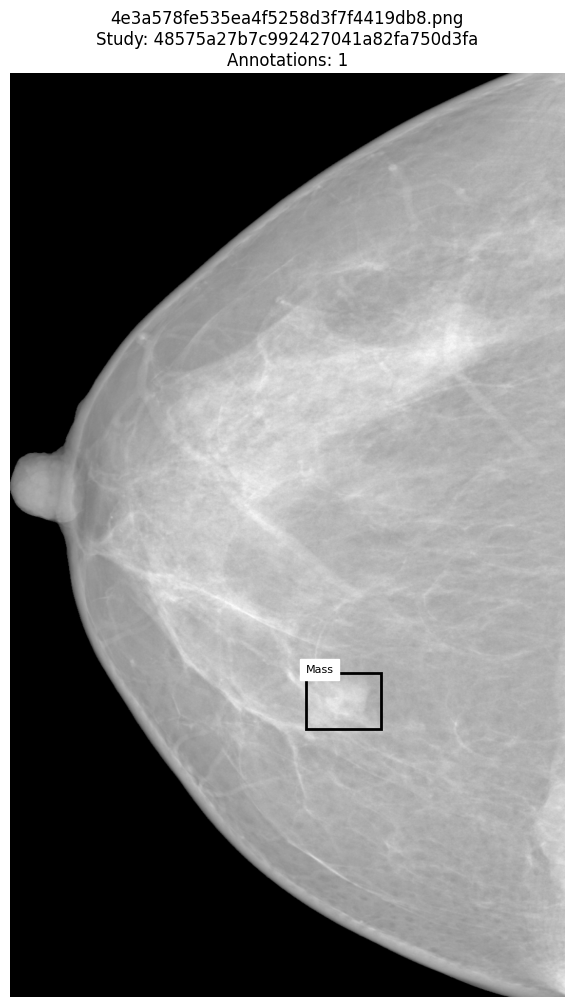

In [ ]:
annotated_images = df[
    df["resized_xmin"].notna()
]["image_id"].unique()

image_id = annotated_images[0]

show_image(
    image_id,
    train_df
)

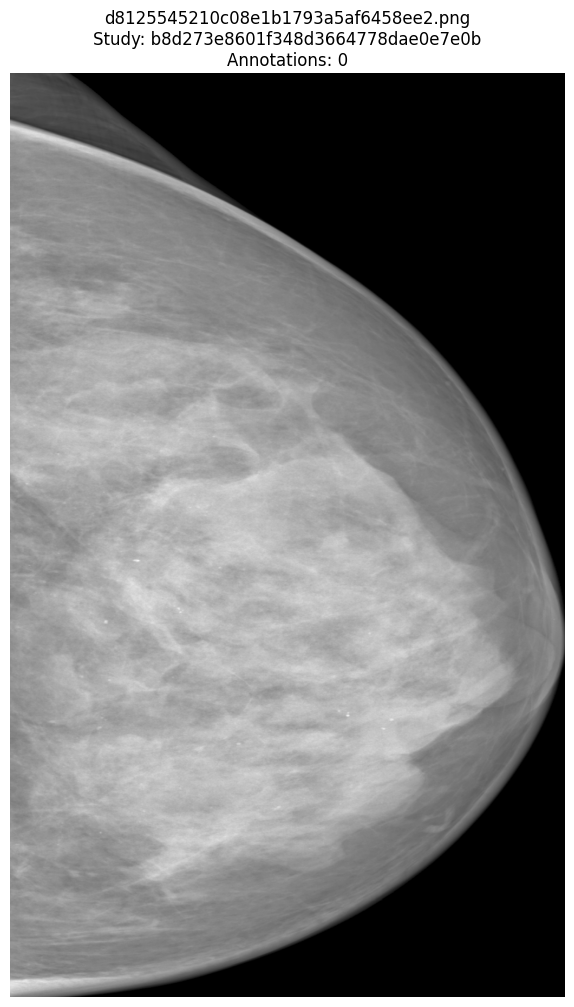

In [ ]:
normal_images = train_df[
    train_df["finding_categories"].astype(str).str.contains("No Finding")
]["image_id"].unique()

normal_id = normal_images[0]

show_image(normal_id, train_df)

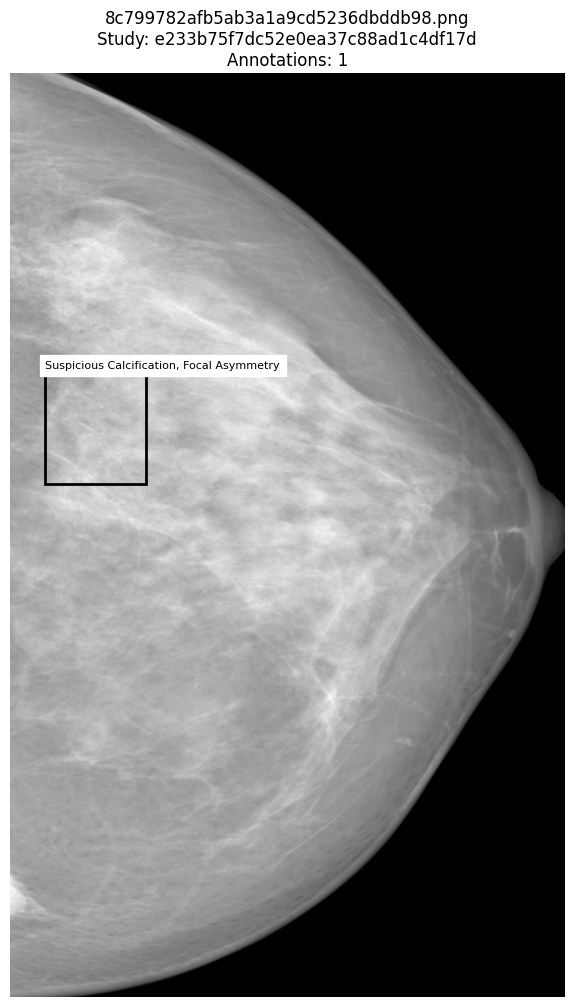

In [ ]:
calc_images = train_df[
    train_df["finding_categories"].astype(str).str.contains(
        "Suspicious Calcification"
    )
]["image_id"].unique()

calc_id = calc_images[0]

show_image(calc_id, train_df)

Multi-finding images: 98


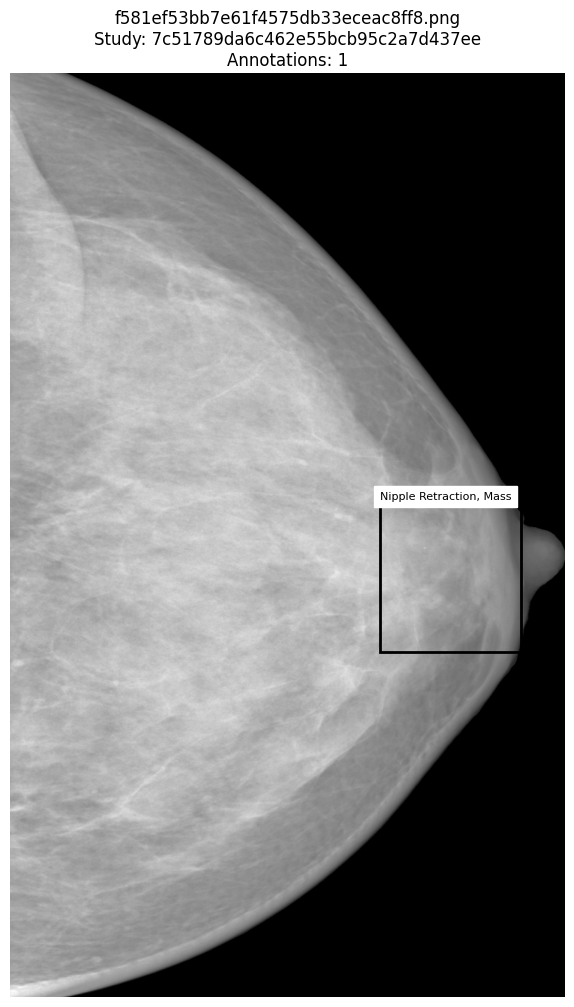

In [ ]:
multi_images = train_df[
    train_df["finding_categories"].astype(str).str.count(",") >= 1
]["image_id"].unique()

print("Multi-finding images:", len(multi_images))

multi_id = multi_images[0]

show_image(multi_id, train_df)

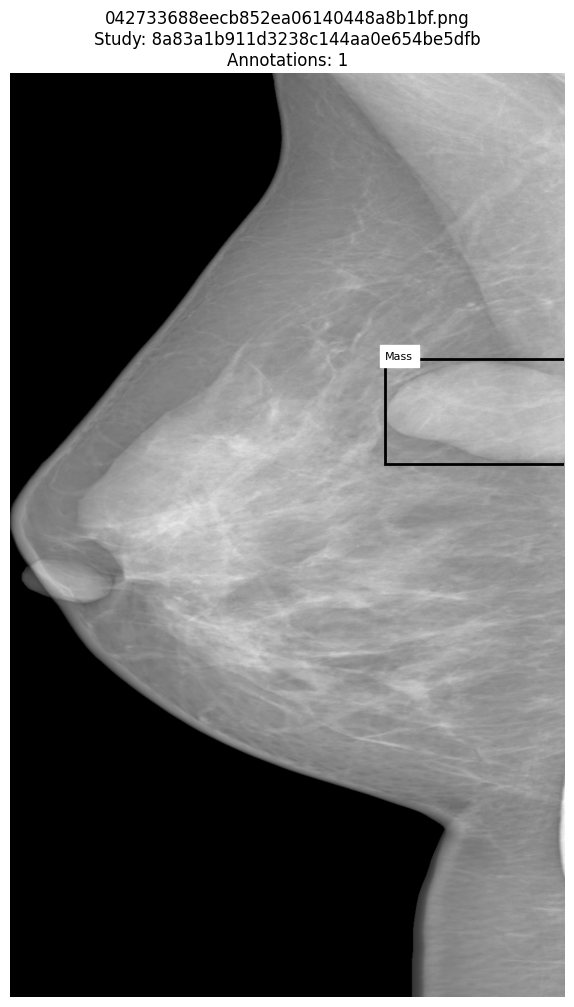

In [ ]:
boundary_id = bbox_df.loc[invalid_png, "image_id"].iloc[0]

show_image(boundary_id, train_df)

In [ ]:
from PIL import Image
import os
from collections import Counter

image_sizes = Counter()

for root, _, files in os.walk(IMAGE_ROOT):
    for file in files:
        if file.endswith(".png"):
            path = os.path.join(root, file)
            with Image.open(path) as img:
                image_sizes[img.size] += 1

print("Unique PNG dimensions:")
for size, count in image_sizes.items():
    print(f"{size}: {count:,} images")

Unique PNG dimensions:
(912, 1520): 20,000 images


In [ ]:
FINDING_CLASSES = [
    "Mass",
    "Suspicious Calcification",
    "Focal Asymmetry",
    "Architectural Distortion",
    "Asymmetry",
    "Suspicious Lymph Node",
    "Skin Thickening",
    "Global Asymmetry",
    "Nipple Retraction",
    "Skin Retraction",
]

CLASS_TO_IDX = {
    name: idx
    for idx, name in enumerate(FINDING_CLASSES)
}

print(CLASS_TO_IDX)

{'Mass': 0, 'Suspicious Calcification': 1, 'Focal Asymmetry': 2, 'Architectural Distortion': 3, 'Asymmetry': 4, 'Suspicious Lymph Node': 5, 'Skin Thickening': 6, 'Global Asymmetry': 7, 'Nipple Retraction': 8, 'Skin Retraction': 9}


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import numpy as np
import ast
import os


class MammoDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_root,
        finding_classes=FINDING_CLASSES
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_root = image_root
        self.finding_classes = finding_classes

        self.class_to_idx = {
            name: idx
            for idx, name in enumerate(finding_classes)
        }

        # Group annotations by image
        self.image_ids = self.df["image_id"].unique().tolist()

        self.image_groups = {
            image_id: group
            for image_id, group
            in self.df.groupby("image_id")
        }

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):

        image_id = self.image_ids[idx]

        rows = self.image_groups[image_id]

        # Study/exam ID = folder containing the image
        study_id = rows.iloc[0]["patient_id"]

        image_path = os.path.join(
            self.image_root,
            study_id,
            image_id
        )

        # Load image
        image = Image.open(image_path).convert("L")

        # Convert to tensor
        image = np.array(image, dtype=np.float32) / 255.0

        image = torch.from_numpy(image).unsqueeze(0)

        # --------------------------------------------------
        # Classification labels
        # --------------------------------------------------

        labels = torch.zeros(
            len(self.finding_classes),
            dtype=torch.float32
        )

        # --------------------------------------------------
        # Detection annotations
        # --------------------------------------------------

        boxes = []
        box_findings = []

        for _, row in rows.iterrows():

            value = row["finding_categories"]

            if pd.isna(value):
                continue

            try:
                findings = ast.literal_eval(str(value))
            except (ValueError, SyntaxError):
                findings = [str(value)]

            if not isinstance(findings, list):
                findings = [findings]

            # Ignore "No Finding"
            findings = [
                finding
                for finding in findings
                if finding != "No Finding"
            ]

            # Add classification labels
            for finding in findings:

                if finding in self.class_to_idx:
                    labels[
                        self.class_to_idx[finding]
                    ] = 1.0

            # Add bounding box if present
            if not pd.isna(row["resized_xmin"]):

                xmin = max(
                    0.0,
                    float(row["resized_xmin"])
                )

                ymin = max(
                    0.0,
                    float(row["resized_ymin"])
                )

                xmax = min(
                    912.0,
                    float(row["resized_xmax"])
                )

                ymax = min(
                    1520.0,
                    float(row["resized_ymax"])
                )

                # Only retain valid boxes after clipping
                if xmax > xmin and ymax > ymin:

                    boxes.append([
                        xmin,
                        ymin,
                        xmax,
                        ymax
                    ])

                    box_findings.append(findings)

        # Convert boxes to tensor
        if len(boxes) > 0:
            boxes = torch.tensor(
                boxes,
                dtype=torch.float32
            )
        else:
            boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32
            )

        return {
            "image": image,
            "labels": labels,
            "boxes": boxes,
            "box_findings": box_findings,
            "image_id": image_id,
            "study_id": study_id
        }

In [ ]:
train_dataset = MammoDataset(
    train_df,
    IMAGE_ROOT
)

val_dataset = MammoDataset(
    val_df,
    IMAGE_ROOT
)

test_dataset = MammoDataset(
    test_df,
    IMAGE_ROOT
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 12800
Validation: 3200
Test: 4000


In [ ]:
sample = train_dataset[0]

print("Image shape:", sample["image"].shape)
print("Labels:", sample["labels"])
print("Boxes shape:", sample["boxes"].shape)
print("Box findings:", sample["box_findings"])
print("Image ID:", sample["image_id"])
print("Study ID:", sample["study_id"])

Image shape: torch.Size([1, 1520, 912])
Labels: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Boxes shape: torch.Size([1, 4])
Box findings: [['Mass']]
Image ID: 4e3a578fe535ea4f5258d3f7f4419db8.png
Study ID: 48575a27b7c992427041a82fa750d3fa


In [ ]:
from torch.utils.data import DataLoader


def mammo_collate_fn(batch):

    images = torch.stack([
        item["image"]
        for item in batch
    ])

    labels = torch.stack([
        item["labels"]
        for item in batch
    ])

    boxes = [
        item["boxes"]
        for item in batch
    ]

    box_findings = [
        item["box_findings"]
        for item in batch
    ]

    image_ids = [
        item["image_id"]
        for item in batch
    ]

    study_ids = [
        item["study_id"]
        for item in batch
    ]

    return {
        "images": images,
        "labels": labels,
        "boxes": boxes,
        "box_findings": box_findings,
        "image_ids": image_ids,
        "study_ids": study_ids
    }

In [ ]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    collate_fn=mammo_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=mammo_collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=mammo_collate_fn
)

In [ ]:
batch = next(iter(train_loader))

print("Images:")
print(batch["images"].shape)

print("\nLabels:")
print(batch["labels"].shape)

print("\nNumber of box sets:")
print(len(batch["boxes"]))

print("\nIndividual box shapes:")
for i, boxes in enumerate(batch["boxes"]):
    print(i, boxes.shape)

print("\nImage IDs:")
for image_id in batch["image_ids"]:
    print(image_id)

Images:
torch.Size([4, 1, 1520, 912])

Labels:
torch.Size([4, 10])

Number of box sets:
4

Individual box shapes:
0 torch.Size([0, 4])
1 torch.Size([0, 4])
2 torch.Size([0, 4])
3 torch.Size([0, 4])

Image IDs:
ef1c9c8dd072e1c43a7172dfddd7660e.png
0972b4844f07018e395a624617c30d0b.png
e6d199b1d117d6a64c3252df344a7334.png
94c5b4b0c671eec84cd46d812a1c4427.png


In [ ]:
for i in range(len(batch["images"])):

    print("=" * 50)
    print("Image:", batch["image_ids"][i])

    print("Labels:")

    active_classes = [
        FINDING_CLASSES[j]
        for j, value in enumerate(batch["labels"][i])
        if value == 1
    ]

    print(active_classes)

    print("Boxes:", batch["boxes"][i].shape[0])
    print("Box findings:", batch["box_findings"][i])

Image: ef1c9c8dd072e1c43a7172dfddd7660e.png
Labels:
[]
Boxes: 0
Box findings: []
Image: 0972b4844f07018e395a624617c30d0b.png
Labels:
[]
Boxes: 0
Box findings: []
Image: e6d199b1d117d6a64c3252df344a7334.png
Labels:
[]
Boxes: 0
Box findings: []
Image: 94c5b4b0c671eec84cd46d812a1c4427.png
Labels:
[]
Boxes: 0
Box findings: []


In [ ]:
# Find a training image that definitely has an annotation
positive_image_ids = train_df[
    train_df["resized_xmin"].notna()
]["image_id"].unique()

# Pick one
positive_id = positive_image_ids[0]

# Find its index in the dataset
positive_idx = train_dataset.image_ids.index(positive_id)

positive_sample = train_dataset[positive_idx]

print("Image ID:", positive_sample["image_id"])
print("Image shape:", positive_sample["image"].shape)

print("\nActive labels:")
print([
    FINDING_CLASSES[i]
    for i, value in enumerate(positive_sample["labels"])
    if value == 1
])

print("\nBoxes:")
print(positive_sample["boxes"])

print("\nBox findings:")
print(positive_sample["box_findings"])

Image ID: 4e3a578fe535ea4f5258d3f7f4419db8.png
Image shape: torch.Size([1, 1520, 912])

Active labels:
['Mass']

Boxes:
tensor([[ 485.6956,  985.7739,  609.5959, 1078.4197]])

Box findings:
[['Mass']]


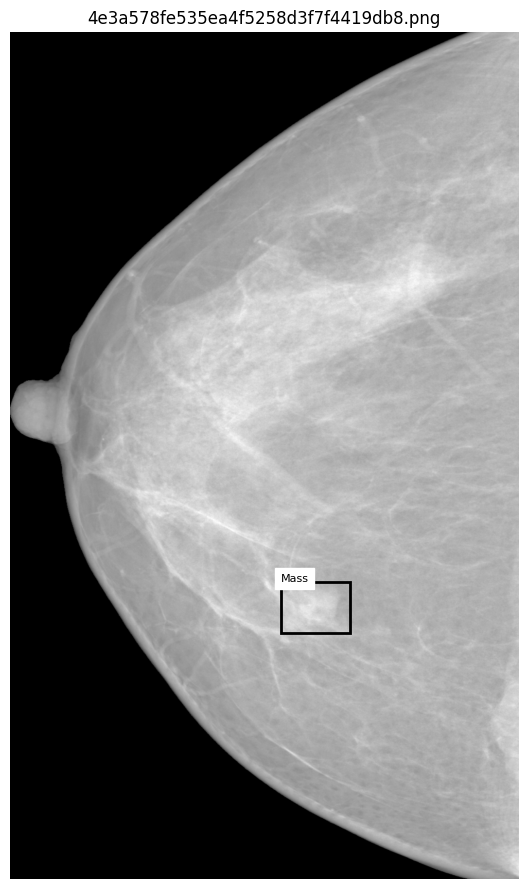

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image = positive_sample["image"].squeeze(0).numpy()

fig, ax = plt.subplots(figsize=(7, 11))

ax.imshow(image, cmap="gray")

for box, findings in zip(
    positive_sample["boxes"],
    positive_sample["box_findings"]
):

    xmin, ymin, xmax, ymax = box.tolist()

    rect = patches.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    ax.text(
        xmin,
        ymin,
        ", ".join(findings),
        fontsize=8,
        backgroundcolor="white"
    )

ax.set_title(positive_sample["image_id"])
ax.axis("off")

plt.show()

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
batch = next(iter(train_loader))

images = batch["images"].to(device)

print("Batch shape:", images.shape)
print("Device:", images.device)

print(
    "GPU memory allocated:",
    round(torch.cuda.memory_allocated() / 1024**2, 2),
    "MB"
)

del images
torch.cuda.empty_cache()

Batch shape: torch.Size([4, 1, 1520, 912])
Device: cuda:0
GPU memory allocated: 22.0 MB


In [ ]:
# Count positive samples for each class from the training dataset

positive_counts = torch.zeros(
    len(FINDING_CLASSES),
    dtype=torch.float32
)

for i in range(len(train_dataset)):

    labels = train_dataset[i]["labels"]

    positive_counts += labels

total_images = len(train_dataset)

negative_counts = total_images - positive_counts

pos_weight = negative_counts / positive_counts

print("Class weights:")
print()

for cls, pos, neg, weight in zip(
    FINDING_CLASSES,
    positive_counts,
    negative_counts,
    pos_weight
):
    print(
        f"{cls:30s} "
        f"positive={int(pos):5d} "
        f"negative={int(neg):5d} "
        f"pos_weight={weight:.2f}"
    )

Class weights:

Mass                           positive=  714 negative=12086 pos_weight=16.93
Suspicious Calcification       positive=  257 negative=12543 pos_weight=48.81
Focal Asymmetry                positive=  168 negative=12632 pos_weight=75.19
Architectural Distortion       positive=   64 negative=12736 pos_weight=199.00
Asymmetry                      positive=   62 negative=12738 pos_weight=205.45
Suspicious Lymph Node          positive=   37 negative=12763 pos_weight=344.95
Skin Thickening                positive=   34 negative=12766 pos_weight=375.47
Global Asymmetry               positive=   16 negative=12784 pos_weight=799.00
Nipple Retraction              positive=   23 negative=12777 pos_weight=555.52
Skin Retraction                positive=   13 negative=12787 pos_weight=983.62


In [ ]:
# Tempered class weights
# Square root reduces the effect of extreme class imbalance

pos_weight_tempered = torch.sqrt(pos_weight)

print("Tempered class weights:")
print()

for cls, weight in zip(FINDING_CLASSES, pos_weight_tempered):
    print(f"{cls:30s} {weight:.2f}")

Tempered class weights:

Mass                           4.11
Suspicious Calcification       6.99
Focal Asymmetry                8.67
Architectural Distortion       14.11
Asymmetry                      14.33
Suspicious Lymph Node          18.57
Skin Thickening                19.38
Global Asymmetry               28.27
Nipple Retraction              23.57
Skin Retraction                31.36


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class MammoCNN(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        # Load ImageNet-pretrained ResNet-18
        self.backbone = models.resnet18(weights="DEFAULT")

        # Save pretrained RGB weights
        old_conv = self.backbone.conv1

        # Create grayscale convolution
        self.backbone.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        # Initialize grayscale filters from pretrained RGB filters
        with torch.no_grad():
            self.backbone.conv1.weight[:] = (
                old_conv.weight.mean(dim=1, keepdim=True)
            )

        # Replace final classifier
        self.backbone.fc = nn.Linear(
            self.backbone.fc.in_features,
            num_classes
        )

    def forward(self, x):
        return self.backbone(x)


model = MammoCNN(
    num_classes=len(FINDING_CLASSES)
).to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


MammoCNN(
  (backbone): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [ ]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight_tempered.to(device)
)

print("Loss function:", criterion)

Loss function: BCEWithLogitsLoss()


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer:", optimizer)

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
batch = next(iter(train_loader))

images = batch["images"].to(device)
labels = batch["labels"].to(device)

optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

loss.backward()

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Loss        :", loss.item())

print(
    "GPU memory allocated:",
    round(torch.cuda.memory_allocated() / 1024**2, 2),
    "MB"
)

optimizer.zero_grad()
del images, labels, outputs, loss
torch.cuda.empty_cache()

Input shape : torch.Size([4, 1, 1520, 912])
Output shape: torch.Size([4, 10])
Loss        : 0.7331541180610657
GPU memory allocated: 126.56 MB


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
from tqdm.auto import tqdm

NUM_EPOCHS = 5

best_val_auroc = -float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "val_auroc": [],
    "val_auprc": []
}

for epoch in range(NUM_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    num_samples = 0

    progress = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )

    for batch in progress:

        images = batch["images"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size
        num_samples += batch_size

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss = running_loss / num_samples

    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_samples = 0

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for batch in val_loader:

            images = batch["images"].to(
                device,
                non_blocking=True
            )

            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            logits = model(images)

            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)

            batch_size = images.size(0)

            val_running_loss += loss.item() * batch_size
            val_samples += batch_size

            all_labels.append(
                labels.cpu().numpy()
            )

            all_probs.append(
                probs.cpu().numpy()
            )

    val_loss = val_running_loss / val_samples

    all_labels = np.concatenate(all_labels, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    # =========================
    # AUROC / AUPRC
    # =========================

    class_aurocs = []
    class_auprcs = []

    for class_idx in range(len(FINDING_CLASSES)):

        y_true = all_labels[:, class_idx]
        y_score = all_probs[:, class_idx]

        # Skip a class if validation has only
        # one label type.
        if len(np.unique(y_true)) < 2:
            continue

        class_aurocs.append(
            roc_auc_score(y_true, y_score)
        )

        class_auprcs.append(
            average_precision_score(y_true, y_score)
        )

    macro_auroc = np.mean(class_aurocs)
    macro_auprc = np.mean(class_auprcs)

    # =========================
    # Save history
    # =========================

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auroc"].append(macro_auroc)
    history["val_auprc"].append(macro_auprc)

    # =========================
    # Save best model
    # =========================

    if macro_auroc > best_val_auroc:

        best_val_auroc = macro_auroc

        torch.save(
            model.state_dict(),
            "/content/MammoGraph/best_cnn_baseline.pth"
        )

        best_marker = " ← BEST"
    else:
        best_marker = ""

    print()
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS}"
    )
    print(
        f"Train Loss : {train_loss:.4f}"
    )
    print(
        f"Val Loss   : {val_loss:.4f}"
    )
    print(
        f"Val AUROC  : {macro_auroc:.4f}{best_marker}"
    )
    print(
        f"Val AUPRC  : {macro_auprc:.4f}"
    )
    print()

Epoch 1/5:   0%|          | 0/3200 [00:00<?, ?it/s]


Epoch 1/5
Train Loss : 0.2892
Val Loss   : 0.2975
Val AUROC  : 0.6051 ← BEST
Val AUPRC  : 0.0284



Epoch 2/5:   0%|          | 0/3200 [00:00<?, ?it/s]


Epoch 2/5
Train Loss : 0.2786
Val Loss   : 0.2979
Val AUROC  : 0.6043
Val AUPRC  : 0.0235



Epoch 3/5:   0%|          | 0/3200 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d94331e520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d94331e520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Epoch 4/5
Train Loss : 0.2742
Val Loss   : 0.3468
Val AUROC  : 0.6327 ← BEST
Val AUPRC  : 0.0277



Epoch 5/5:   0%|          | 0/3200 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d94331e520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d94331e520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Epoch 5/5
Train Loss : 0.2739
Val Loss   : 0.7460
Val AUROC  : 0.6285
Val AUPRC  : 0.0232



In [ ]:
import os

checkpoint_path = "/content/MammoGraph/best_cnn_baseline.pth"

print("Exists:", os.path.exists(checkpoint_path))

if os.path.exists(checkpoint_path):
    print(
        "Size:",
        round(os.path.getsize(checkpoint_path) / 1024**2, 2),
        "MB"
    )

Exists: True
Size: 42.71 MB


In [ ]:
# ============================================================
# CNN BASELINE — FULL TEST SET EVALUATION
# ============================================================

import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Load best CNN checkpoint
# ------------------------------------------------------------

checkpoint_path = "/content/MammoGraph/best_cnn_baseline.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model.to(device)
model.eval()

print("Loaded:", checkpoint_path)


# ------------------------------------------------------------
# 2. Run inference on TEST set
# ------------------------------------------------------------

all_labels = []
all_probs = []

with torch.no_grad():

    for batch in test_loader:

        images = batch["images"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        logits = model(images)

        probs = torch.sigmoid(logits)

        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())


y_true = np.concatenate(all_labels, axis=0)
y_prob = np.concatenate(all_probs, axis=0)

print("Test samples:", len(y_true))
print("Shape:", y_true.shape)


# ------------------------------------------------------------
# 3. Convert probabilities to binary predictions
# ------------------------------------------------------------

THRESHOLD = 0.5

y_pred = (y_prob >= THRESHOLD).astype(int)


# ------------------------------------------------------------
# 4. Class names
# ------------------------------------------------------------

class_names = FINDING_CLASSES


# ------------------------------------------------------------
# 5. Calculate metrics
# ------------------------------------------------------------

results = {}

# Exact-match accuracy
results["Exact Match Accuracy"] = accuracy_score(
    y_true,
    y_pred
)

# Micro accuracy
results["Micro Accuracy"] = accuracy_score(
    y_true.flatten(),
    y_pred.flatten()
)

# Balanced accuracy
balanced_acc_per_class = []

for i in range(len(class_names)):

    # balanced_accuracy_score requires both classes
    if len(np.unique(y_true[:, i])) == 2:
        score = balanced_accuracy_score(
            y_true[:, i],
            y_pred[:, i]
        )
        balanced_acc_per_class.append(score)

results["Macro Balanced Accuracy"] = np.mean(
    balanced_acc_per_class
)


# F1
results["Macro F1"] = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

results["Micro F1"] = f1_score(
    y_true,
    y_pred,
    average="micro",
    zero_division=0
)


# Precision
results["Macro Precision"] = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

results["Micro Precision"] = precision_score(
    y_true,
    y_pred,
    average="micro",
    zero_division=0
)


# Recall / Sensitivity
results["Macro Sensitivity / Recall"] = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

results["Micro Sensitivity / Recall"] = recall_score(
    y_true,
    y_pred,
    average="micro",
    zero_division=0
)


# AUROC
auroc_scores = []

for i in range(len(class_names)):

    if len(np.unique(y_true[:, i])) == 2:

        score = roc_auc_score(
            y_true[:, i],
            y_prob[:, i]
        )

        auroc_scores.append(score)

results["Macro AUROC"] = np.mean(auroc_scores)


# AUPRC
auprc_scores = []

for i in range(len(class_names)):

    if np.sum(y_true[:, i]) > 0:

        score = average_precision_score(
            y_true[:, i],
            y_prob[:, i]
        )

        auprc_scores.append(score)

results["Macro AUPRC"] = np.mean(auprc_scores)


# ------------------------------------------------------------
# 6. Specificity
# ------------------------------------------------------------

specificity_scores = []

for i in range(len(class_names)):

    tn, fp, fn, tp = confusion_matrix(
        y_true[:, i],
        y_pred[:, i],
        labels=[0, 1]
    ).ravel()

    if (tn + fp) > 0:

        specificity = tn / (tn + fp)

        specificity_scores.append(specificity)

results["Macro Specificity"] = np.mean(
    specificity_scores
)


# ------------------------------------------------------------
# 7. Per-class metrics
# ------------------------------------------------------------

per_class = {}

for i, class_name in enumerate(class_names):

    true = y_true[:, i]
    pred = y_pred[:, i]
    prob = y_prob[:, i]

    tn, fp, fn, tp = confusion_matrix(
        true,
        pred,
        labels=[0, 1]
    ).ravel()

    # Sensitivity
    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else np.nan
    )

    # Specificity
    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    # Balanced accuracy
    if (tp + fn) > 0 and (tn + fp) > 0:
        balanced_accuracy = (
            sensitivity + specificity
        ) / 2
    else:
        balanced_accuracy = np.nan

    # AUROC
    if len(np.unique(true)) == 2:
        auroc = roc_auc_score(true, prob)
    else:
        auroc = np.nan

    # AUPRC
    if np.sum(true) > 0:
        auprc = average_precision_score(true, prob)
    else:
        auprc = np.nan

    per_class[class_name] = {

        "Accuracy": accuracy_score(true, pred),

        "Balanced Accuracy": balanced_accuracy,

        "Precision": precision_score(
            true,
            pred,
            zero_division=0
        ),

        "Sensitivity / Recall": sensitivity,

        "Specificity": specificity,

        "F1": f1_score(
            true,
            pred,
            zero_division=0
        ),

        "AUROC": auroc,

        "AUPRC": auprc,

        "TP": int(tp),
        "FP": int(fp),
        "TN": int(tn),
        "FN": int(fn)
    }


# ------------------------------------------------------------
# 8. Print overall results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CNN BASELINE — TEST SET RESULTS")
print("=" * 70)

for metric, value in results.items():

    print(
        f"{metric:<35}: {value:.4f}"
    )


# ------------------------------------------------------------
# 9. Print per-class results
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("PER-CLASS RESULTS")
print("=" * 100)

header = (
    f"{'Class':<28}"
    f"{'Acc':>8}"
    f"{'BalAcc':>9}"
    f"{'Precision':>11}"
    f"{'Recall':>9}"
    f"{'Specificity':>13}"
    f"{'F1':>8}"
    f"{'AUROC':>9}"
    f"{'AUPRC':>9}"
)

print(header)
print("-" * 100)

for class_name, metrics in per_class.items():

    print(
        f"{class_name:<28}"
        f"{metrics['Accuracy']:>8.4f}"
        f"{metrics['Balanced Accuracy']:>9.4f}"
        f"{metrics['Precision']:>11.4f}"
        f"{metrics['Sensitivity / Recall']:>9.4f}"
        f"{metrics['Specificity']:>13.4f}"
        f"{metrics['F1']:>8.4f}"
        f"{metrics['AUROC']:>9.4f}"
        f"{metrics['AUPRC']:>9.4f}"
    )


# ------------------------------------------------------------
# 10. Save everything to TXT
# ------------------------------------------------------------

output_path = "/content/MammoGraph/cnn_baseline_metrics.txt"

with open(output_path, "w") as f:

    f.write("MammoGraph — CNN Baseline Test Evaluation\n")
    f.write("=" * 70 + "\n\n")

    f.write("MODEL\n")
    f.write("-" * 70 + "\n")
    f.write("Architecture: ResNet-18\n")
    f.write("Dataset: VinDr-Mammo\n")
    f.write("Task: 10-class multilabel abnormal finding classification\n")
    f.write("Checkpoint: best_cnn_baseline.pth\n")
    f.write("Threshold: 0.5\n\n")

    f.write("OVERALL TEST METRICS\n")
    f.write("-" * 70 + "\n")

    for metric, value in results.items():

        f.write(
            f"{metric:<35}: {value:.6f}\n"
        )

    f.write("\n\n")

    f.write("PER-CLASS METRICS\n")
    f.write("=" * 100 + "\n")

    f.write(header + "\n")
    f.write("-" * 100 + "\n")

    for class_name, metrics in per_class.items():

        f.write(
            f"{class_name:<28}"
            f"{metrics['Accuracy']:>8.4f}"
            f"{metrics['Balanced Accuracy']:>9.4f}"
            f"{metrics['Precision']:>11.4f}"
            f"{metrics['Sensitivity / Recall']:>9.4f}"
            f"{metrics['Specificity']:>13.4f}"
            f"{metrics['F1']:>8.4f}"
            f"{metrics['AUROC']:>9.4f}"
            f"{metrics['AUPRC']:>9.4f}\n"
        )

    f.write("\n\nCONFUSION COUNTS PER CLASS\n")
    f.write("=" * 70 + "\n")

    for class_name, metrics in per_class.items():

        f.write(f"\n{class_name}\n")
        f.write(f"TP: {metrics['TP']}\n")
        f.write(f"FP: {metrics['FP']}\n")
        f.write(f"TN: {metrics['TN']}\n")
        f.write(f"FN: {metrics['FN']}\n")


print("\n" + "=" * 70)
print("Saved metrics to:")
print(output_path)
print("=" * 70)

Loaded: /content/MammoGraph/best_cnn_baseline.pth


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d94331e520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78d94331e520>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Test samples: 4000
Shape: (4000, 10)

CNN BASELINE — TEST SET RESULTS
Exact Match Accuracy               : 0.8492
Micro Accuracy                     : 0.9689
Macro Balanced Accuracy            : 0.5434
Macro F1                           : 0.0503
Micro F1                           : 0.1129
Macro Precision                    : 0.0395
Micro Precision                    : 0.0838
Macro Sensitivity / Recall         : 0.1089
Micro Sensitivity / Recall         : 0.1729
Macro AUROC                        : 0.6373
Macro AUPRC                        : 0.0326
Macro Specificity                  : 0.9779

PER-CLASS RESULTS
Class                            Acc   BalAcc  Precision   Recall  Specificity      F1    AUROC    AUPRC
----------------------------------------------------------------------------------------------------
Mass                          0.8880   0.5536     0.1270   0.1781       0.9291  0.1483   0.5765   0.1046
Suspicious Calcification      0.9503   0.6130     0.1824   0.2571       

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import pandas as pd
import ast
import os

DETECTION_CLASSES = [
    "Mass",
    "Suspicious Calcification",
    "Focal Asymmetry",
    "Architectural Distortion",
    "Asymmetry",
    "Suspicious Lymph Node",
    "Skin Thickening",
    "Global Asymmetry",
    "Nipple Retraction",
    "Skin Retraction",
]

CLASS_TO_IDX = {
    name: idx + 1
    for idx, name in enumerate(DETECTION_CLASSES)
}
# 0 is reserved for background

print(CLASS_TO_IDX)

{'Mass': 1, 'Suspicious Calcification': 2, 'Focal Asymmetry': 3, 'Architectural Distortion': 4, 'Asymmetry': 5, 'Suspicious Lymph Node': 6, 'Skin Thickening': 7, 'Global Asymmetry': 8, 'Nipple Retraction': 9, 'Skin Retraction': 10}


In [ ]:
class MammoDetectionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_root,
        classes=DETECTION_CLASSES
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_root = image_root
        self.classes = classes

        self.image_ids = self.df["image_id"].unique().tolist()

        self.image_groups = {
            image_id: group
            for image_id, group
            in self.df.groupby("image_id")
        }

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):

        image_id = self.image_ids[idx]
        rows = self.image_groups[image_id]

        study_id = rows.iloc[0]["patient_id"]

        image_path = os.path.join(
            self.image_root,
            study_id,
            image_id
        )

        # Load grayscale image
        image = Image.open(image_path).convert("L")
        image = np.array(image, dtype=np.float32) / 255.0

        # Convert to 3 channels for torchvision pretrained backbone
        image = np.stack([image, image, image], axis=0)

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        boxes = []
        labels = []

        for _, row in rows.iterrows():

            if pd.isna(row["resized_xmin"]):
                continue

            # Already in 912 x 1520 PNG coordinates
            xmin = max(0.0, float(row["resized_xmin"]))
            ymin = max(0.0, float(row["resized_ymin"]))
            xmax = min(912.0, float(row["resized_xmax"]))
            ymax = min(1520.0, float(row["resized_ymax"]))

            # Ignore invalid boxes
            if xmax <= xmin or ymax <= ymin:
                continue

            value = row["finding_categories"]

            if pd.isna(value):
                continue

            try:
                findings = ast.literal_eval(str(value))
            except (ValueError, SyntaxError):
                findings = [str(value)]

            if not isinstance(findings, list):
                findings = [findings]

            # A box can potentially correspond to multiple findings.
            # For detection baseline, create one target per finding.
            for finding in findings:

                if finding not in CLASS_TO_IDX:
                    continue

                boxes.append([
                    xmin,
                    ymin,
                    xmax,
                    ymax
                ])

                labels.append(
                    CLASS_TO_IDX[finding]
                )

        if len(boxes) > 0:

            boxes = torch.tensor(
                boxes,
                dtype=torch.float32
            )

            labels = torch.tensor(
                labels,
                dtype=torch.int64
            )

        else:

            boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32
            )

            labels = torch.zeros(
                (0,),
                dtype=torch.int64
            )

        # Required by torchvision detectors
        area = (
            (boxes[:, 2] - boxes[:, 0]) *
            (boxes[:, 3] - boxes[:, 1])
        )

        iscrowd = torch.zeros(
            (len(boxes),),
            dtype=torch.int64
        )

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": iscrowd
        }

        return image, target

In [ ]:
train_detection_dataset = MammoDetectionDataset(train_df, IMAGE_ROOT)
val_detection_dataset = MammoDetectionDataset(val_df, IMAGE_ROOT)
test_detection_dataset = MammoDetectionDataset(test_df, IMAGE_ROOT)

print("Train:", len(train_detection_dataset))
print("Val:", len(val_detection_dataset))
print("Test:", len(test_detection_dataset))

Train: 12800
Val: 3200
Test: 4000


In [ ]:
image, target = train_detection_dataset[0]

print("Image shape:", image.shape)
print("Boxes shape:", target["boxes"].shape)
print("Boxes:")
print(target["boxes"])

print("\nLabels:")
print(target["labels"])

Image shape: torch.Size([3, 1520, 912])
Boxes shape: torch.Size([1, 4])
Boxes:
tensor([[ 485.6956,  985.7739,  609.5959, 1078.4197]])

Labels:
tensor([1])


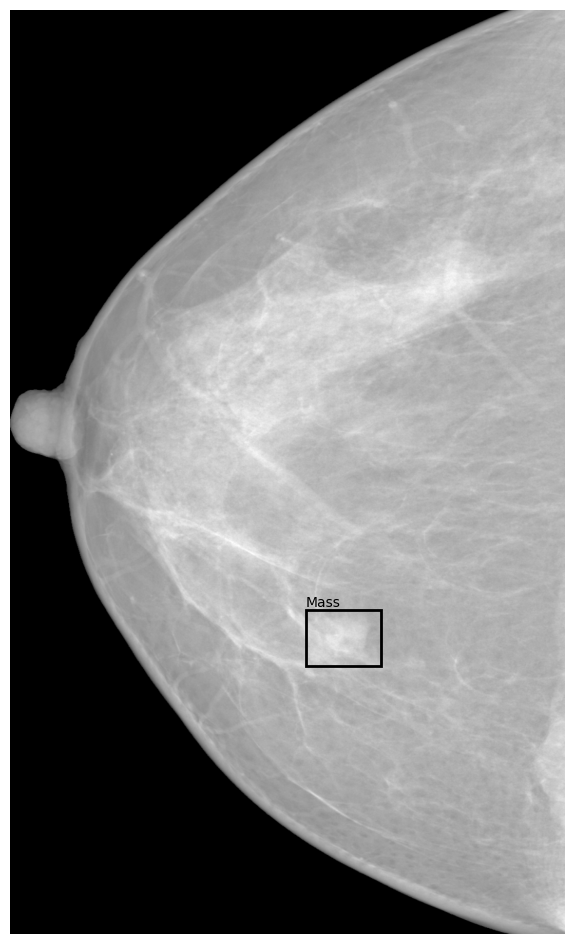

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

image, target = train_detection_dataset[0]

# Convert CHW -> HWC
img = image[0].numpy()

fig, ax = plt.subplots(figsize=(8, 12))

ax.imshow(img, cmap="gray")

for box, label in zip(target["boxes"], target["labels"]):

    xmin, ymin, xmax, ymax = box.numpy()

    rect = patches.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rect)

    ax.text(
        xmin,
        ymin - 5,
        DETECTION_CLASSES[label.item() - 1],
        fontsize=10
    )

ax.axis("off")
plt.show()

In [ ]:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models import ResNet50_Weights

In [ ]:
NUM_CLASSES = len(DETECTION_CLASSES) + 1  # + background

detector = fasterrcnn_resnet50_fpn(
    weights="DEFAULT",
    min_size=800,
    max_size=1333
)

# Replace classification head for our 10 finding classes + background
in_features = detector.roi_heads.box_predictor.cls_score.in_features

detector.roi_heads.box_predictor = (
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features,
        NUM_CLASSES
    )
)

detector = detector.to(device)

print("Number of classes:", NUM_CLASSES)
print("Detector:", type(detector).__name__)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 172MB/s]


Number of classes: 11
Detector: FasterRCNN


In [ ]:
from torch.utils.data import DataLoader

def detection_collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


BATCH_SIZE_DET = 1

train_detection_loader = DataLoader(
    train_detection_dataset,
    batch_size=BATCH_SIZE_DET,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=detection_collate_fn
)

val_detection_loader = DataLoader(
    val_detection_dataset,
    batch_size=BATCH_SIZE_DET,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=detection_collate_fn
)

test_detection_loader = DataLoader(
    test_detection_dataset,
    batch_size=BATCH_SIZE_DET,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=detection_collate_fn
)

print("Detection DataLoaders created.")

Detection DataLoaders created.


In [ ]:
images, targets = next(iter(train_detection_loader))

print("Number of images:", len(images))
print("Image shape:", images[0].shape)

print("Number of targets:", len(targets))
print("Boxes:", targets[0]["boxes"].shape)
print("Labels:", targets[0]["labels"])

Number of images: 1
Image shape: torch.Size([3, 1520, 912])
Number of targets: 1
Boxes: torch.Size([0, 4])
Labels: tensor([], dtype=torch.int64)


In [ ]:
# Find the first training sample containing at least one box

for i in range(len(train_detection_dataset)):
    image, target = train_detection_dataset[i]

    if len(target["boxes"]) > 0:
        print("Found positive sample at index:", i)
        print("Image shape:", image.shape)
        print("Boxes:", target["boxes"])
        print("Labels:", target["labels"])
        break

Found positive sample at index: 0
Image shape: torch.Size([3, 1520, 912])
Boxes: tensor([[ 485.6956,  985.7739,  609.5959, 1078.4197]])
Labels: tensor([1])


In [ ]:
# Get one positive sample
image, target = train_detection_dataset[0]

images = [image.to(device)]

targets = [{
    k: v.to(device)
    for k, v in target.items()
}]

detector.train()

loss_dict = detector(
    images,
    targets
)

total_loss = sum(loss for loss in loss_dict.values())

print("Individual losses:")
for name, loss in loss_dict.items():
    print(f"{name}: {loss.item():.4f}")

print(f"\nTotal loss: {total_loss.item():.4f}")

Individual losses:
loss_classifier: 2.3780
loss_box_reg: 0.0012
loss_objectness: 0.1544
loss_rpn_box_reg: 0.0096

Total loss: 2.5431


In [ ]:
detector_optimizer = torch.optim.AdamW(
    detector.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer ready.")

Optimizer ready.


In [ ]:
detector.train()

images, targets = next(iter(train_detection_loader))

images = [
    image.to(device)
    for image in images
]

targets = [
    {
        k: v.to(device)
        for k, v in target.items()
    }
    for target in targets
]

detector_optimizer.zero_grad()

loss_dict = detector(
    images,
    targets
)

loss = sum(loss for loss in loss_dict.values())

loss.backward()

detector_optimizer.step()

print("Training step successful.")
print("Loss:", loss.item())

Training step successful.
Loss: 2.4494996070861816


In [ ]:
print(f"GPU allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU allocated: 1.46 GB
GPU reserved:  2.52 GB


In [ ]:
import time
import copy

NUM_EPOCHS_DET = 5

best_val_loss = float("inf")
best_detector_state = None

train_history_det = []
val_history_det = []

for epoch in range(NUM_EPOCHS_DET):

    # =====================================================
    # TRAINING
    # =====================================================

    detector.train()

    train_loss = 0.0
    start_time = time.time()

    total_train_batches = len(train_detection_loader)

    for batch_idx, (images, targets) in enumerate(train_detection_loader):

        images = [
            image.to(device)
            for image in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]

        detector_optimizer.zero_grad()

        loss_dict = detector(
            images,
            targets
        )

        loss = sum(
            loss_value
            for loss_value in loss_dict.values()
        )

        loss.backward()
        detector_optimizer.step()

        train_loss += loss.item()

        # ---------------------------------------------
        # Progress display
        # ---------------------------------------------
        if (
            (batch_idx + 1) % 50 == 0
            or (batch_idx + 1) == total_train_batches
        ):

            avg_loss = train_loss / (batch_idx + 1)

            elapsed = time.time() - start_time

            progress = (batch_idx + 1) / total_train_batches * 100

            print(
                f"\rEpoch {epoch + 1}/{NUM_EPOCHS_DET} | "
                f"Train [{batch_idx + 1}/{total_train_batches}] "
                f"{progress:5.1f}% | "
                f"Loss: {avg_loss:.4f} | "
                f"Time: {elapsed / 60:.1f} min",
                end=""
            )

    train_loss /= total_train_batches

    print()  # move to next line


    # =====================================================
    # VALIDATION
    # =====================================================

    # Faster R-CNN returns losses only in train mode
    detector.train()

    val_loss = 0.0

    total_val_batches = len(val_detection_loader)

    val_start_time = time.time()

    with torch.no_grad():

        for batch_idx, (images, targets) in enumerate(
            val_detection_loader
        ):

            images = [
                image.to(device)
                for image in images
            ]

            targets = [
                {
                    k: v.to(device)
                    for k, v in target.items()
                }
                for target in targets
            ]

            loss_dict = detector(
                images,
                targets
            )

            loss = sum(
                loss_value
                for loss_value in loss_dict.values()
            )

            val_loss += loss.item()

            # ---------------------------------------------
            # Validation progress
            # ---------------------------------------------
            if (
                (batch_idx + 1) % 50 == 0
                or (batch_idx + 1) == total_val_batches
            ):

                avg_val_loss = val_loss / (batch_idx + 1)

                progress = (
                    (batch_idx + 1)
                    / total_val_batches
                    * 100
                )

                elapsed = time.time() - val_start_time

                print(
                    f"\rEpoch {epoch + 1}/{NUM_EPOCHS_DET} | "
                    f"Val   [{batch_idx + 1}/{total_val_batches}] "
                    f"{progress:5.1f}% | "
                    f"Loss: {avg_val_loss:.4f} | "
                    f"Time: {elapsed / 60:.1f} min",
                    end=""
                )

    val_loss /= total_val_batches

    print()


    # =====================================================
    # EPOCH SUMMARY
    # =====================================================

    elapsed = time.time() - start_time

    train_history_det.append(train_loss)
    val_history_det.append(val_loss)

    print(
        f"\nEpoch {epoch + 1}/{NUM_EPOCHS_DET} COMPLETE | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Time: {elapsed / 60:.1f} min"
    )


    # =====================================================
    # SAVE BEST MODEL
    # =====================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_detector_state = copy.deepcopy(
            detector.state_dict()
        )

        torch.save(
            best_detector_state,
            "/content/MammoGraph/best_fasterrcnn_baseline.pth"
        )

        print("✓ Best detector checkpoint saved")


print("\nTraining complete.")
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 1/5 | Train [2300/12800]  18.0% | Loss: 0.0470 | Time: 12.7 min

KeyboardInterrupt: 

In [ ]:
# Small detection subset for pipeline testing

TRAIN_DET_DEBUG = 1000
VAL_DET_DEBUG = 200

train_detection_debug = torch.utils.data.Subset(
    train_detection_dataset,
    range(TRAIN_DET_DEBUG)
)

val_detection_debug = torch.utils.data.Subset(
    val_detection_dataset,
    range(VAL_DET_DEBUG)
)

train_detection_loader = DataLoader(
    train_detection_debug,
    batch_size=1,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=detection_collate_fn
)

val_detection_loader = DataLoader(
    val_detection_debug,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=detection_collate_fn
)

print("Debug train:", len(train_detection_debug))
print("Debug val:", len(val_detection_debug))

Debug train: 1000
Debug val: 200


In [ ]:
NUM_EPOCHS_DEBUG = 2

for epoch in range(NUM_EPOCHS_DEBUG):

    detector.train()

    train_loss = 0.0
    start_time = time.time()

    for batch_idx, (images, targets) in enumerate(train_detection_loader):

        images = [
            image.to(device)
            for image in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]

        detector_optimizer.zero_grad()

        loss_dict = detector(
            images,
            targets
        )

        loss = sum(loss_dict.values())

        loss.backward()
        detector_optimizer.step()

        train_loss += loss.item()

        # Progress every 50 batches
        if (batch_idx + 1) % 50 == 0:

            elapsed = time.time() - start_time

            print(
                f"Epoch {epoch + 1}/{NUM_EPOCHS_DEBUG} | "
                f"Batch {batch_idx + 1}/{len(train_detection_loader)} | "
                f"Loss: {loss.item():.4f} | "
                f"Time: {elapsed / 60:.1f} min"
            )

    train_loss /= len(train_detection_loader)

    print(
        f"\nEpoch {epoch + 1} complete | "
        f"Average Train Loss: {train_loss:.4f}\n"
    )

Epoch 1/2 | Batch 50/1000 | Loss: 0.2314 | Time: 0.3 min
Epoch 1/2 | Batch 100/1000 | Loss: 0.1636 | Time: 0.6 min
Epoch 1/2 | Batch 150/1000 | Loss: 0.4784 | Time: 0.9 min
Epoch 1/2 | Batch 200/1000 | Loss: 0.5248 | Time: 1.2 min
Epoch 1/2 | Batch 250/1000 | Loss: 0.5491 | Time: 1.5 min
Epoch 1/2 | Batch 300/1000 | Loss: 0.2914 | Time: 1.8 min
Epoch 1/2 | Batch 350/1000 | Loss: 0.1965 | Time: 2.1 min
Epoch 1/2 | Batch 400/1000 | Loss: 0.4951 | Time: 2.4 min
Epoch 1/2 | Batch 450/1000 | Loss: 0.2134 | Time: 2.7 min
Epoch 1/2 | Batch 500/1000 | Loss: 0.1839 | Time: 2.9 min
Epoch 1/2 | Batch 550/1000 | Loss: 0.4358 | Time: 3.2 min
Epoch 1/2 | Batch 600/1000 | Loss: 0.2451 | Time: 3.5 min
Epoch 1/2 | Batch 650/1000 | Loss: 0.2169 | Time: 3.8 min
Epoch 1/2 | Batch 700/1000 | Loss: 0.2699 | Time: 4.1 min
Epoch 1/2 | Batch 750/1000 | Loss: 0.1833 | Time: 4.4 min
Epoch 1/2 | Batch 800/1000 | Loss: 0.2610 | Time: 4.7 min
Epoch 1/2 | Batch 850/1000 | Loss: 0.2721 | Time: 5.0 min
Epoch 1/2 | Bat

In [ ]:
import json
import os
import torch

# Save model checkpoint
debug_detector_path = "/content/MammoGraph/fasterrcnn_debug_1000.pth"

torch.save(
    detector.state_dict(),
    debug_detector_path
)

# Store training metrics
debug_metrics = {
    "model": "Faster R-CNN",
    "backbone": "ResNet-50 FPN",
    "dataset": "VinDr-Mammo",
    "task": "10-class object detection",
    "train_samples": len(train_detection_debug),
    "validation_samples": len(val_detection_debug),
    "epochs": NUM_EPOCHS_DEBUG,
    "batch_size": 1,
    "optimizer": "AdamW",
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "train_loss": train_loss,
}

metrics_path = "/content/MammoGraph/fasterrcnn_debug_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(debug_metrics, f, indent=4)

print("Model saved:", debug_detector_path)
print("Metrics saved:", metrics_path)

Model saved: /content/MammoGraph/fasterrcnn_debug_1000.pth
Metrics saved: /content/MammoGraph/fasterrcnn_debug_metrics.json


GNT Construction

In [150]:
# ============================================================
# MammoGraph — GNT Configuration
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import ast
import os

from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# Image dimensions
# ------------------------------------------------------------

IMAGE_WIDTH = 912.0
IMAGE_HEIGHT = 1520.0


# ------------------------------------------------------------
# ResNet feature map dimensions
# ------------------------------------------------------------

FEATURE_H = 48
FEATURE_W = 29

NUM_NODES = FEATURE_H * FEATURE_W

print("Nodes per image:", NUM_NODES)


# ------------------------------------------------------------
# GNT configuration
# ------------------------------------------------------------

GNT_HIDDEN_DIM = 256
GNT_NUM_HEADS = 8
GNT_NUM_LAYERS = 2

GRAPH_K = 8

NUM_CLASSES = len(FINDING_CLASSES)

print("Finding classes:", NUM_CLASSES)
print("Graph k:", GRAPH_K)
print("GNT hidden dimension:", GNT_HIDDEN_DIM)

Device: cuda
GPU: Tesla T4
Nodes per image: 1392
Finding classes: 10
Graph k: 8
GNT hidden dimension: 256


In [151]:
# ============================================================
# GNT Dataset
# ============================================================

class MammoGNTDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_root,
        finding_classes=FINDING_CLASSES
    ):

        self.df = dataframe.reset_index(drop=True)
        self.image_root = image_root
        self.finding_classes = finding_classes

        self.class_to_idx = {
            name: idx
            for idx, name in enumerate(finding_classes)
        }

        # One dataset item = one mammogram image
        self.image_ids = (
            self.df["image_id"]
            .unique()
            .tolist()
        )

        self.image_groups = {
            image_id: group
            for image_id, group
            in self.df.groupby("image_id")
        }


    def __len__(self):
        return len(self.image_ids)


    def __getitem__(self, idx):

        image_id = self.image_ids[idx]

        rows = self.image_groups[image_id]

        study_id = rows.iloc[0]["patient_id"]

        image_path = os.path.join(
            self.image_root,
            study_id,
            image_id
        )


        # ----------------------------------------------------
        # Load mammogram
        # ----------------------------------------------------

        image = Image.open(image_path).convert("L")

        image = np.array(
            image,
            dtype=np.float32
        ) / 255.0

        image = torch.from_numpy(
            image
        ).unsqueeze(0)


        # ----------------------------------------------------
        # Image-level multilabel target
        # ----------------------------------------------------

        image_labels = torch.zeros(
            len(self.finding_classes),
            dtype=torch.float32
        )


        # ----------------------------------------------------
        # Bounding-box targets
        # ----------------------------------------------------

        boxes = []

        box_labels = []

        box_findings = []


        for _, row in rows.iterrows():

            value = row["finding_categories"]

            if pd.isna(value):
                continue


            # Parse finding list
            try:

                findings = ast.literal_eval(
                    str(value)
                )

            except (ValueError, SyntaxError):

                findings = [str(value)]


            if not isinstance(findings, list):
                findings = [findings]


            # Remove "No Finding"
            findings = [
                finding
                for finding in findings
                if finding != "No Finding"
            ]


            # ------------------------------------------------
            # Image-level labels
            # ------------------------------------------------

            for finding in findings:

                if finding in self.class_to_idx:

                    image_labels[
                        self.class_to_idx[finding]
                    ] = 1.0


            # ------------------------------------------------
            # Bounding box
            # ------------------------------------------------

            if pd.isna(row["resized_xmin"]):
                continue


            # These coordinates are already in the
            # 912 x 1520 PNG coordinate system.
            #
            # Clip small boundary overflows.
            # ------------------------------------------------

            xmin = max(
                0.0,
                float(row["resized_xmin"])
            )

            ymin = max(
                0.0,
                float(row["resized_ymin"])
            )

            xmax = min(
                IMAGE_WIDTH,
                float(row["resized_xmax"])
            )

            ymax = min(
                IMAGE_HEIGHT,
                float(row["resized_ymax"])
            )


            # Reject invalid boxes

            if xmax <= xmin or ymax <= ymin:
                continue


            # ------------------------------------------------
            # Multilabel target for THIS box
            # ------------------------------------------------

            box_label = torch.zeros(
                len(self.finding_classes),
                dtype=torch.float32
            )

            valid_findings = []


            for finding in findings:

                if finding in self.class_to_idx:

                    class_idx = self.class_to_idx[
                        finding
                    ]

                    box_label[class_idx] = 1.0

                    valid_findings.append(
                        finding
                    )


            if len(valid_findings) == 0:
                continue


            boxes.append([
                xmin,
                ymin,
                xmax,
                ymax
            ])

            box_labels.append(
                box_label
            )

            box_findings.append(
                valid_findings
            )


        # ----------------------------------------------------
        # Convert boxes
        # ----------------------------------------------------

        if len(boxes) > 0:

            boxes = torch.tensor(
                boxes,
                dtype=torch.float32
            )

            box_labels = torch.stack(
                box_labels
            )

        else:

            boxes = torch.zeros(
                (0, 4),
                dtype=torch.float32
            )

            box_labels = torch.zeros(
                (0, len(self.finding_classes)),
                dtype=torch.float32
            )


        return {

            "image": image,

            "labels": image_labels,

            "boxes": boxes,

            "box_labels": box_labels,

            "box_findings": box_findings,

            "image_id": image_id,

            "study_id": study_id
        }

In [152]:
# ============================================================
# Create GNT datasets
# ============================================================

train_dataset = MammoGNTDataset(
    train_df,
    IMAGE_ROOT
)

val_dataset = MammoGNTDataset(
    val_df,
    IMAGE_ROOT
)

test_dataset = MammoGNTDataset(
    test_df,
    IMAGE_ROOT
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))

Train images: 12800
Validation images: 3200
Test images: 4000


In [153]:
# ============================================================
# Verify multi-finding bounding boxes
# ============================================================

multi_finding_count = 0
positive_box_count = 0

for idx in range(len(train_dataset)):

    sample = train_dataset[idx]

    positive_box_count += len(
        sample["boxes"]
    )

    for findings in sample["box_findings"]:

        if len(findings) > 1:

            multi_finding_count += 1

            if multi_finding_count <= 5:

                print(
                    "Image:",
                    sample["image_id"]
                )

                print(
                    "Findings:",
                    findings
                )

                print(
                    "Box label:",
                    sample["box_labels"][
                        len(
                            sample["box_findings"][:]
                        ) - len(
                            sample["box_findings"]
                        )
                    ]
                    if False else
                    "multilabel preserved"
                )

                print()


print(
    "Total positive boxes:",
    positive_box_count
)

print(
    "Multi-finding boxes:",
    multi_finding_count
)

Image: f581ef53bb7e61f4575db33eceac8ff8.png
Findings: ['Nipple Retraction', 'Mass']
Box label: multilabel preserved

Image: 1142cdfbfe725d62038252693cf064e5.png
Findings: ['Nipple Retraction', 'Mass']
Box label: multilabel preserved

Image: 8c799782afb5ab3a1a9cd5236dbddb98.png
Findings: ['Suspicious Calcification', 'Focal Asymmetry']
Box label: multilabel preserved

Image: a869427ece4cb34d43825be65705929b.png
Findings: ['Suspicious Calcification', 'Focal Asymmetry']
Box label: multilabel preserved

Image: 5fd515ea4eaec3493943c4eef796b41e.png
Findings: ['Suspicious Calcification', 'Focal Asymmetry']
Box label: multilabel preserved

Total positive boxes: 1406
Multi-finding boxes: 106


In [154]:
# ============================================================
# GNT Collate Function
# ============================================================

def gnt_collate_fn(batch):

    return {

        "images": torch.stack([
            item["image"]
            for item in batch
        ]),

        "labels": torch.stack([
            item["labels"]
            for item in batch
        ]),

        "boxes": [
            item["boxes"]
            for item in batch
        ],

        "box_labels": [
            item["box_labels"]
            for item in batch
        ],

        "box_findings": [
            item["box_findings"]
            for item in batch
        ],

        "image_ids": [
            item["image_id"]
            for item in batch
        ],

        "study_ids": [
            item["study_id"]
            for item in batch
        ]
    }

In [155]:
# ============================================================
# Positive-aware training sampler
# ============================================================

positive_indices = []
negative_indices = []


for idx, image_id in enumerate(
    train_dataset.image_ids
):

    sample = train_dataset[idx]

    if len(sample["boxes"]) > 0:
        positive_indices.append(idx)
    else:
        negative_indices.append(idx)


print(
    "Positive images:",
    len(positive_indices)
)

print(
    "Negative images:",
    len(negative_indices)
)


# ------------------------------------------------------------
# Sampling weights
# ------------------------------------------------------------

num_samples = len(train_dataset)

sample_weights = torch.zeros(
    num_samples,
    dtype=torch.double
)


sample_weights[
    positive_indices
] = 0.5 / len(positive_indices)


sample_weights[
    negative_indices
] = 0.5 / len(negative_indices)


train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=num_samples,
    replacement=True
)

print("Positive-aware sampler ready.")

Positive images: 1110
Negative images: 11690
Positive-aware sampler ready.


In [156]:
# ============================================================
# GNT DataLoaders
# ============================================================

BATCH_SIZE = 4


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=0,
    pin_memory=True,
    collate_fn=gnt_collate_fn
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=gnt_collate_fn
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=gnt_collate_fn
)


print("DataLoaders ready.")

DataLoaders ready.


In [157]:
# ============================================================
# Visual Feature Extractor
# ============================================================

class MammogramFeatureExtractor(nn.Module):

    def __init__(self):

        super().__init__()

        backbone = models.resnet18(
            weights="DEFAULT"
        )


        # ----------------------------------------------------
        # Convert RGB first convolution → grayscale
        # ----------------------------------------------------

        old_conv = backbone.conv1

        backbone.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )


        # Average pretrained RGB weights
        with torch.no_grad():

            backbone.conv1.weight[:] = (
                old_conv.weight.mean(
                    dim=1,
                    keepdim=True
                )
            )


        # ----------------------------------------------------
        # Remove classification head
        # ----------------------------------------------------

        self.features = nn.Sequential(

            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,

            backbone.layer1,
            backbone.layer2,
            backbone.layer3,
            backbone.layer4
        )


    def forward(self, x):

        return self.features(x)

In [158]:
# ============================================================
# Feature extractor
# ============================================================

feature_extractor = MammogramFeatureExtractor().to(device)

feature_extractor.eval()

for parameter in feature_extractor.parameters():

    parameter.requires_grad = False


print("Feature extractor ready.")
print("Parameters frozen.")

Feature extractor ready.
Parameters frozen.


In [159]:
# ============================================================
# Convert CNN feature map into graph nodes
# ============================================================

def feature_map_to_nodes(features):

    # features:
    # [B, C, H, W]

    B, C, H, W = features.shape


    # [B, C, H, W]
    # →
    # [B, H, W, C]

    features = features.permute(
        0, 2, 3, 1
    )


    # →
    # [B, H*W, C]

    features = features.reshape(
        B,
        H * W,
        C
    )


    # --------------------------------------------------------
    # Spatial coordinates
    # --------------------------------------------------------

    x = torch.linspace(
        IMAGE_WIDTH / (2 * W),
        IMAGE_WIDTH - IMAGE_WIDTH / (2 * W),
        W,
        device=features.device
    )

    y = torch.linspace(
        IMAGE_HEIGHT / (2 * H),
        IMAGE_HEIGHT - IMAGE_HEIGHT / (2 * H),
        H,
        device=features.device
    )


    yy, xx = torch.meshgrid(
        y,
        x,
        indexing="ij"
    )


    coordinates = torch.stack(
        [xx, yy],
        dim=-1
    )


    coordinates = coordinates.reshape(
        H * W,
        2
    )


    # Normalize coordinates to [0,1]

    coordinates[:, 0] /= IMAGE_WIDTH
    coordinates[:, 1] /= IMAGE_HEIGHT


    coordinates = coordinates.unsqueeze(0)


    coordinates = coordinates.expand(
        B,
        -1,
        -1
    )


    # --------------------------------------------------------
    # Node = visual feature + spatial coordinates
    # --------------------------------------------------------

    nodes = torch.cat(
        [
            features,
            coordinates
        ],
        dim=-1
    )


    return nodes

In [160]:
# ============================================================
# Spatial kNN graph
# ============================================================

def build_spatial_knn_graph(
    nodes,
    k=GRAPH_K
):

    # nodes:
    # [B, N, D]

    B, N, D = nodes.shape


    # Coordinates are the last two dimensions

    coordinates = nodes[:, :, -2:]


    # Pairwise spatial distance

    distances = torch.cdist(
        coordinates,
        coordinates
    )


    # Remove self connections

    distances[
        torch.arange(N, device=nodes.device),
        torch.arange(N, device=nodes.device)
    ] = float("inf")


    # k nearest neighbors

    neighbors = torch.topk(
        distances,
        k=k,
        dim=-1,
        largest=False
    ).indices


    # --------------------------------------------------------
    # Build directed edges
    # --------------------------------------------------------

    source = torch.arange(
        N,
        device=nodes.device
    ).view(1, N, 1).expand(
        B,
        N,
        k
    )


    edge_index = torch.stack(
        [
            source.reshape(B, -1),
            neighbors.reshape(B, -1)
        ],
        dim=1
    )


    return edge_index

In [161]:
# ============================================================
# Graph Transformer Layer
# ============================================================

class GraphTransformerLayer(nn.Module):

    def __init__(
        self,
        hidden_dim=256,
        num_heads=8,
        dropout=0.1
    ):

        super().__init__()

        assert hidden_dim % num_heads == 0


        self.hidden_dim = hidden_dim
        self.num_heads = num_heads

        self.head_dim = (
            hidden_dim // num_heads
        )


        # ----------------------------------------------------
        # QKV projections
        # ----------------------------------------------------

        self.q_proj = nn.Linear(
            hidden_dim,
            hidden_dim
        )

        self.k_proj = nn.Linear(
            hidden_dim,
            hidden_dim
        )

        self.v_proj = nn.Linear(
            hidden_dim,
            hidden_dim
        )


        self.out_proj = nn.Linear(
            hidden_dim,
            hidden_dim
        )


        # ----------------------------------------------------
        # Normalization
        # ----------------------------------------------------

        self.norm1 = nn.LayerNorm(
            hidden_dim
        )

        self.norm2 = nn.LayerNorm(
            hidden_dim
        )


        # ----------------------------------------------------
        # Feed-forward network
        # ----------------------------------------------------

        self.ffn = nn.Sequential(

            nn.Linear(
                hidden_dim,
                hidden_dim * 4
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim * 4,
                hidden_dim
            ),

            nn.Dropout(dropout)
        )


    def forward(
        self,
        x,
        edge_index
    ):

        # x:
        # [N, D]

        N = x.shape[0]


        # ----------------------------------------------------
        # Q K V
        # ----------------------------------------------------

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)


        # [N,D]
        # →
        # [N,H,D_head]

        q = q.view(
            N,
            self.num_heads,
            self.head_dim
        )

        k = k.view(
            N,
            self.num_heads,
            self.head_dim
        )

        v = v.view(
            N,
            self.num_heads,
            self.head_dim
        )


        source = edge_index[0]
        target = edge_index[1]


        # ----------------------------------------------------
        # Attention scores
        # ----------------------------------------------------

        q_source = q[source]

        k_target = k[target]

        scores = (
            q_source * k_target
        ).sum(dim=-1)

        scores /= np.sqrt(
            self.head_dim
        )


        # ----------------------------------------------------
        # Stable source-wise softmax
        # ----------------------------------------------------

        max_scores = torch.full(
            (N, self.num_heads),
            -float("inf"),
            device=x.device
        )


        max_scores.scatter_reduce_(
            0,
            source.unsqueeze(-1).expand(
                -1,
                self.num_heads
            ),
            scores,
            reduce="amax",
            include_self=True
        )


        scores_exp = torch.exp(
            scores
            - max_scores[source]
        )


        denominator = torch.zeros(
            N,
            self.num_heads,
            device=x.device
        )


        denominator.scatter_add_(
            0,
            source.unsqueeze(-1).expand(
                -1,
                self.num_heads
            ),
            scores_exp
        )


        attention = (
            scores_exp
            / (
                denominator[source]
                + 1e-8
            )
        )


        # ----------------------------------------------------
        # Weighted message aggregation
        # ----------------------------------------------------

        messages = (
            v[target]
            * attention.unsqueeze(-1)
        )


        aggregated = torch.zeros(
            N,
            self.num_heads,
            self.head_dim,
            device=x.device
        )


        aggregated.index_add_(
            0,
            source,
            messages
        )


        aggregated = aggregated.reshape(
            N,
            self.hidden_dim
        )


        # ----------------------------------------------------
        # Residual attention block
        # ----------------------------------------------------

        x = self.norm1(
            x
            + self.out_proj(
                aggregated
            )
        )


        # ----------------------------------------------------
        # Feed-forward block
        # ----------------------------------------------------

        x = self.norm2(
            x
            + self.ffn(x)
        )


        return x

In [162]:
# ============================================================
# MammoGNT
# ============================================================

class MammoGNT(nn.Module):

    def __init__(
        self,
        input_dim=514,
        hidden_dim=256,
        num_heads=8,
        num_layers=2,
        num_classes=10
    ):

        super().__init__()


        # ----------------------------------------------------
        # Node projection
        # ----------------------------------------------------

        self.node_projection = nn.Linear(
            input_dim,
            hidden_dim
        )


        # ----------------------------------------------------
        # Graph Transformer
        # ----------------------------------------------------

        self.layers = nn.ModuleList([

            GraphTransformerLayer(
                hidden_dim=hidden_dim,
                num_heads=num_heads
            )

            for _ in range(num_layers)
        ])


        # ----------------------------------------------------
        # Image-level classification
        # ----------------------------------------------------

        self.image_norm = nn.LayerNorm(
            hidden_dim
        )

        self.image_classifier = nn.Linear(
            hidden_dim,
            num_classes
        )


        # ----------------------------------------------------
        # Node objectness
        # ----------------------------------------------------

        self.objectness_head = nn.Linear(
            hidden_dim,
            1
        )


        # ----------------------------------------------------
        # Node finding classification
        # ----------------------------------------------------

        self.node_classifier = nn.Linear(
            hidden_dim,
            num_classes
        )


        # ----------------------------------------------------
        # Bounding-box regression
        # ----------------------------------------------------

        self.bbox_regressor = nn.Linear(
            hidden_dim,
            4
        )


    def forward(
        self,
        nodes,
        edge_indices
    ):

        B, N, _ = nodes.shape


        # ----------------------------------------------------
        # Project nodes
        # ----------------------------------------------------

        x = self.node_projection(
            nodes
        )


        # ----------------------------------------------------
        # Graph Transformer
        # ----------------------------------------------------

        for layer in self.layers:

            updated_nodes = []

            for b in range(B):

                updated = layer(
                    x[b],
                    edge_indices[b]
                )

                updated_nodes.append(
                    updated
                )

            x = torch.stack(
                updated_nodes,
                dim=0
            )


        # ----------------------------------------------------
        # Image-level classification
        # ----------------------------------------------------

        pooled = x.mean(
            dim=1
        )

        pooled = self.image_norm(
            pooled
        )

        image_logits = (
            self.image_classifier(
                pooled
            )
        )


        # ----------------------------------------------------
        # Node-level outputs
        # ----------------------------------------------------

        objectness = (
            self.objectness_head(x)
        )

        node_logits = (
            self.node_classifier(x)
        )


        # Sigmoid because bbox coordinates
        # are normalized to [0,1].

        box_predictions = torch.sigmoid(
            self.bbox_regressor(x)
        )


        return {

            "logits": image_logits,

            "node_features": x,

            "objectness": objectness,

            "node_logits": node_logits,

            "box_predictions": box_predictions
        }

In [163]:
# ============================================================
# Create GNT model
# ============================================================

gnt_model = MammoGNT(
    input_dim=514,
    hidden_dim=GNT_HIDDEN_DIM,
    num_heads=GNT_NUM_HEADS,
    num_layers=GNT_NUM_LAYERS,
    num_classes=NUM_CLASSES
).to(device)


print(gnt_model)

MammoGNT(
  (node_projection): Linear(in_features=514, out_features=256, bias=True)
  (layers): ModuleList(
    (0-1): 2 x GraphTransformerLayer(
      (q_proj): Linear(in_features=256, out_features=256, bias=True)
      (k_proj): Linear(in_features=256, out_features=256, bias=True)
      (v_proj): Linear(in_features=256, out_features=256, bias=True)
      (out_proj): Linear(in_features=256, out_features=256, bias=True)
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): Sequential(
        (0): Linear(in_features=256, out_features=1024, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=1024, out_features=256, bias=True)
        (4): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (image_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (image_classifier): Linear(in_features=256, out_features=10, bias

In [164]:
# ============================================================
# Graph node coordinates
# ============================================================

def get_node_coordinates():

    x = torch.linspace(
        IMAGE_WIDTH / (2 * FEATURE_W),
        IMAGE_WIDTH - IMAGE_WIDTH / (2 * FEATURE_W),
        FEATURE_W
    )

    y = torch.linspace(
        IMAGE_HEIGHT / (2 * FEATURE_H),
        IMAGE_HEIGHT - IMAGE_HEIGHT / (2 * FEATURE_H),
        FEATURE_H
    )


    yy, xx = torch.meshgrid(
        y,
        x,
        indexing="ij"
    )


    coordinates = torch.stack(
        [xx, yy],
        dim=-1
    )


    return coordinates.reshape(
        -1,
        2
    )


node_coords = get_node_coordinates()

print(
    "Node coordinates:",
    node_coords.shape
)

print(
    "First node:",
    node_coords[0]
)

print(
    "Last node:",
    node_coords[-1]
)

Node coordinates: torch.Size([1392, 2])
First node: tensor([15.7241, 15.8333])
Last node: tensor([ 896.2759, 1504.1666])


In [165]:
# ============================================================
# Node assignment
# ============================================================

def assign_nodes_to_box(
    node_coords,
    box
):

    xmin, ymin, xmax, ymax = box


    inside = (

        (node_coords[:, 0] >= xmin)
        &
        (node_coords[:, 0] <= xmax)
        &
        (node_coords[:, 1] >= ymin)
        &
        (node_coords[:, 1] <= ymax)

    )

    return inside

In [166]:
# ============================================================
# Build GNT training targets
# ============================================================

def build_gnt_targets(
    target,
    node_coords,
    num_classes=NUM_CLASSES
):

    N = node_coords.shape[0]


    # --------------------------------------------------------
    # Initialize targets
    # --------------------------------------------------------

    objectness_target = torch.zeros(
        N,
        dtype=torch.float32
    )

    node_class_target = torch.zeros(
        N,
        num_classes,
        dtype=torch.float32
    )

    node_class_mask = torch.zeros(
        N,
        dtype=torch.bool
    )

    bbox_target = torch.zeros(
        N,
        4,
        dtype=torch.float32
    )

    bbox_mask = torch.zeros(
        N,
        dtype=torch.bool
    )


    # Track closest box assigned to each node

    node_box_distance = torch.full(
        (N,),
        float("inf")
    )


    boxes = target["boxes"]

    box_labels = target["box_labels"]


    # --------------------------------------------------------
    # Process every ground-truth box
    # --------------------------------------------------------

    for box, box_label in zip(
        boxes,
        box_labels
    ):


        positive_nodes = assign_nodes_to_box(
            node_coords,
            box
        )


        positive_indices = torch.where(
            positive_nodes
        )[0]


        # ----------------------------------------------------
        # If no node lies inside the box
        # ----------------------------------------------------

        if len(positive_indices) == 0:

            center_x = (
                box[0] + box[2]
            ) / 2

            center_y = (
                box[1] + box[3]
            ) / 2


            distances = (

                (node_coords[:, 0] - center_x) ** 2

                +

                (node_coords[:, 1] - center_y) ** 2

            )


            nearest = torch.argmin(
                distances
            )


            positive_indices = (
                nearest.unsqueeze(0)
            )


        # ----------------------------------------------------
        # Objectness
        # ----------------------------------------------------

        objectness_target[
            positive_indices
        ] = 1.0


        # ----------------------------------------------------
        # Multilabel node classification
        # ----------------------------------------------------

        node_class_target[
            positive_indices
        ] = torch.maximum(
            node_class_target[
                positive_indices
            ],
            box_label.unsqueeze(0)
        )


        node_class_mask[
            positive_indices
        ] = True


        # ----------------------------------------------------
        # Bbox assignment
        # ----------------------------------------------------

        center_x = (
            box[0] + box[2]
        ) / 2

        center_y = (
            box[1] + box[3]
        ) / 2


        node_x = node_coords[
            positive_indices,
            0
        ]

        node_y = node_coords[
            positive_indices,
            1
        ]


        distances = (

            (node_x - center_x) ** 2

            +

            (node_y - center_y) ** 2

        )


        current_distances = (
            node_box_distance[
                positive_indices
            ]
        )


        closer = (
            distances
            < current_distances
        )


        closer_indices = (
            positive_indices[closer]
        )


        if len(closer_indices) > 0:

            normalized_box = torch.tensor([

                box[0] / IMAGE_WIDTH,

                box[1] / IMAGE_HEIGHT,

                box[2] / IMAGE_WIDTH,

                box[3] / IMAGE_HEIGHT

            ], dtype=torch.float32)


            bbox_target[
                closer_indices
            ] = normalized_box


            bbox_mask[
                closer_indices
            ] = True


            node_box_distance[
                closer_indices
            ] = distances[closer]


    return {

        "objectness":
            objectness_target,

        "node_class":
            node_class_target,

        "node_class_mask":
            node_class_mask,

        "bbox":
            bbox_target,

        "bbox_mask":
            bbox_mask
    }

In [167]:
# ============================================================
# GNT Multi-task Loss
# ============================================================

OBJECTNESS_POS_WEIGHT = 10.0


def gnt_loss(
    outputs,
    targets,
    image_labels
):


    # --------------------------------------------------------
    # Image-level classification
    # --------------------------------------------------------

    image_loss = F.binary_cross_entropy_with_logits(
        outputs["logits"],
        image_labels
    )


    objectness_losses = []
    node_class_losses = []
    bbox_losses = []


    for b in range(len(targets)):

        target = targets[b]


        objectness_target = (
            target["objectness"]
            .to(device)
        )

        node_class_target = (
            target["node_class"]
            .to(device)
        )

        node_class_mask = (
            target["node_class_mask"]
            .to(device)
        )

        bbox_target = (
            target["bbox"]
            .to(device)
        )

        bbox_mask = (
            target["bbox_mask"]
            .to(device)
        )


        # ----------------------------------------------------
        # Objectness
        # ----------------------------------------------------

        objectness_pred = (
            outputs["objectness"][
                b, :, 0
            ]
        )


        pos_weight = torch.tensor(
            OBJECTNESS_POS_WEIGHT,
            device=device
        )


        objectness_loss = (
            F.binary_cross_entropy_with_logits(
                objectness_pred,
                objectness_target,
                pos_weight=pos_weight
            )
        )


        objectness_losses.append(
            objectness_loss
        )


        # ----------------------------------------------------
        # Node classification
        # ----------------------------------------------------

        if node_class_mask.any():

            node_pred = (
                outputs["node_logits"][
                    b,
                    node_class_mask
                ]
            )

            node_target = (
                node_class_target[
                    node_class_mask
                ]
            )


            node_class_loss = (
                F.binary_cross_entropy_with_logits(
                    node_pred,
                    node_target
                )
            )


            node_class_losses.append(
                node_class_loss
            )


        # ----------------------------------------------------
        # Bounding-box regression
        # ----------------------------------------------------

        if bbox_mask.any():

            bbox_pred = (
                outputs["box_predictions"][
                    b,
                    bbox_mask
                ]
            )

            bbox_gt = (
                bbox_target[
                    bbox_mask
                ]
            )


            bbox_loss = F.smooth_l1_loss(
                bbox_pred,
                bbox_gt
            )


            bbox_losses.append(
                bbox_loss
            )


    # --------------------------------------------------------
    # Aggregate
    # --------------------------------------------------------

    objectness_loss = torch.stack(
        objectness_losses
    ).mean()


    if len(node_class_losses) > 0:

        node_class_loss = torch.stack(
            node_class_losses
        ).mean()

    else:

        node_class_loss = torch.tensor(
            0.0,
            device=device
        )


    if len(bbox_losses) > 0:

        bbox_loss = torch.stack(
            bbox_losses
        ).mean()

    else:

        bbox_loss = torch.tensor(
            0.0,
            device=device
        )


    # --------------------------------------------------------
    # Total
    # --------------------------------------------------------

    total_loss = (
        image_loss
        + objectness_loss
        + node_class_loss
        + bbox_loss
    )


    return {

        "total":
            total_loss,

        "image":
            image_loss,

        "objectness":
            objectness_loss,

        "node_class":
            node_class_loss,

        "bbox":
            bbox_loss
    }

In [168]:
# ============================================================
# GNT Optimizer
# ============================================================

gnt_optimizer = torch.optim.AdamW(
    gnt_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Optimizer ready.")

Optimizer ready.


In [169]:
# ============================================================
# GNT Forward Pass Sanity Check
# ============================================================

gnt_model.eval()


batch = next(
    iter(train_loader)
)


images = batch["images"].to(
    device,
    non_blocking=True
)

image_labels = batch["labels"].to(
    device,
    non_blocking=True
)


# ------------------------------------------------------------
# CNN feature extraction
# ------------------------------------------------------------

with torch.no_grad():

    feature_map = feature_extractor(
        images
    )


# ------------------------------------------------------------
# Convert features → nodes
# ------------------------------------------------------------

nodes = feature_map_to_nodes(
    feature_map
)


# ------------------------------------------------------------
# Graph construction
# ------------------------------------------------------------

edge_indices = build_spatial_knn_graph(
    nodes,
    k=GRAPH_K
)


# ------------------------------------------------------------
# GNT forward
# ------------------------------------------------------------

with torch.no_grad():

    outputs = gnt_model(
        nodes,
        edge_indices
    )


print("Images:")
print(images.shape)

print()

print("Feature map:")
print(feature_map.shape)

print()

print("Nodes:")
print(nodes.shape)

print()

print("Edges:")
print(edge_indices.shape)

print()

print("GNT outputs:")

for key, value in outputs.items():

    print(
        key,
        ":",
        value.shape
    )

Images:
torch.Size([4, 1, 1520, 912])

Feature map:
torch.Size([4, 512, 48, 29])

Nodes:
torch.Size([4, 1392, 514])

Edges:
torch.Size([4, 2, 11136])

GNT outputs:
logits : torch.Size([4, 10])
node_features : torch.Size([4, 1392, 256])
objectness : torch.Size([4, 1392, 1])
node_logits : torch.Size([4, 1392, 10])
box_predictions : torch.Size([4, 1392, 4])


In [170]:
# ============================================================
# Build GNT targets
# ============================================================

targets = []

for b in range(
    len(batch["images"])
):

    target = build_gnt_targets(
        {
            "boxes":
                batch["boxes"][b],

            "box_labels":
                batch["box_labels"][b]
        },

        node_coords,
        num_classes=NUM_CLASSES
    )

    targets.append(
        target
    )


for i, target in enumerate(targets):

    print(
        f"Image {i}:"
    )

    print(
        "  Positive nodes:",
        int(
            target["objectness"].sum()
        )
    )

    print(
        "  BBox nodes:",
        int(
            target["bbox_mask"].sum()
        )
    )

    print(
        "  Positive classes:",
        torch.where(
            target["node_class"].sum(dim=0) > 0
        )[0].tolist()
    )

Image 0:
  Positive nodes: 0
  BBox nodes: 0
  Positive classes: []
Image 1:
  Positive nodes: 45
  BBox nodes: 45
  Positive classes: [0]
Image 2:
  Positive nodes: 150
  BBox nodes: 150
  Positive classes: [2]
Image 3:
  Positive nodes: 148
  BBox nodes: 148
  Positive classes: [0, 1, 5]


In [172]:
# ============================================================
# GNT Loss + Backward Sanity Check
# ============================================================

gnt_model.train()

gnt_optimizer.zero_grad()


# Re-run forward with gradients

feature_map = feature_extractor(
    images
)


nodes = feature_map_to_nodes(
    feature_map
)


edge_indices = build_spatial_knn_graph(
    nodes,
    k=GRAPH_K
)


outputs = gnt_model(
    nodes,
    edge_indices
)


losses = gnt_loss(
    outputs,
    targets,
    image_labels
)


losses["total"].backward()


# ------------------------------------------------------------
# Gradient check
# ------------------------------------------------------------

total_gradient = 0.0

for parameter in gnt_model.parameters():

    if parameter.grad is not None:

        total_gradient += (
            parameter.grad.abs()
            .sum()
            .item()
        )


print("Losses:")

for key, value in losses.items():

    print(
        f"{key:12s}: "
        f"{value.item():.6f}"
    )


print()

print(
    "Total gradient magnitude:",
    total_gradient
)

RuntimeError: cuDNN error: CUDNN_STATUS_EXECUTION_FAILED